In [1]:
# Import Libraries
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import ks_2samp, wasserstein_distance
import matplotlib.colors as mcolors
from scipy.stats import kruskal
from scipy.signal import welch
from scipy.stats import entropy as sp_entropy
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

## Import and Prepare Data

Import signals from PhysioNet Gait in Parkinson's Dataset

In [2]:
col_names = ['Time',
             'L1','L2','L3','L4','L5','L6','L7','L8',
             'R1','R2','R3','R4','R5','R6','R7','R8',
             'L_Total','R_Total']

def load_gait_data(data_dir, demographics_path):
    """Load all gait files and merge with demographic data."""

    # Load demographics
    demo = pd.read_excel(demographics_path)
    demo_dict = demo.set_index('ID').to_dict('index')

    records = []
    for filepath in Path(data_dir).glob('*.txt'):
        filename = filepath.stem

        if 'Co' in filename:
            label = 0
        elif 'Pt' in filename:
            label = 1
        else:
            continue

        walk_num = filename.split('_')[1]
        dual_task = 1 if walk_num == '10' else 0
        subject_id = filename.split('_')[0]

        data = pd.read_csv(filepath, sep='\t', header=None,
                           names=col_names)

        record = {
            'filename': filename,
            'subject_id': subject_id,
            'label': label,
            'dual_task': dual_task,
            'L1': data['L1'].values,
            'L2': data['L2'].values,
            'L3': data['L3'].values,
            'L4': data['L4'].values,
            'L5': data['L5'].values,
            'L6': data['L6'].values,
            'L7': data['L7'].values,
            'L8': data['L8'].values,
            'R1': data['R1'].values,
            'R2': data['R2'].values,
            'R3': data['R3'].values,
            'R4': data['R4'].values,
            'R5': data['R5'].values,
            'R6': data['R6'].values,
            'R7': data['R7'].values,
            'R8': data['R8'].values,
            'R_Total': data['R_Total'].values,
            'L_Total': data['L_Total'].values,
        }

        # Merge demographic data
        if subject_id in demo_dict:
            d = demo_dict[subject_id]
            record['age'] = d.get('Age')
            record['gender'] = d.get('Gender')
            record['height_m'] = d.get('Height (meters)')
            record['weight_kg'] = d.get('Weight (kg)')
            record['hoehn_yahr'] = d.get('HoehnYahr')
            record['updrs'] = d.get('UPDRS')
            record['updrsm'] = d.get('UPDRSM')
            record['speed_01'] = d.get('Speed_01 (m/sec)')
            record['study'] = d.get('Study')
        else:
            record.update({k: None for k in
                ['age','gender','height_m','weight_kg',
                 'hoehn_yahr','updrs','updrsm','speed_01','study']})

        records.append(record)

    return records

# Usage
# data_dir = 'C:/Users/simon/PycharmProjects/ParkinsonsDetection/gait-in-parkinsons-disease-1.0.0'
# demographics_path = ('C:/Users/simon/PycharmProjects/ParkinsonsDetection/gait-in-parkinsons-disease-1.0.0/demographics.xls')
data_dir = 'ParkinsonsDetection/gait-in-parkinsons-disease-1.0.0'
demographics_path = ('ParkinsonsDetection/gait-in-parkinsons-disease-1.0.0/demographics.xls')
all_data = load_gait_data(data_dir, demographics_path)

# Quick check
matched = sum(1 for d in all_data if d['weight_kg'] is not None)
print(f"Loaded {len(all_data)} files, {matched} matched to demographics")

Loaded 306 files, 306 matched to demographics


In [3]:
for record in all_data:
    if record['label'] == 0:
        for key in ['hoehn_yahr', 'updrs', 'updrsm']:
            if record[key] is None or pd.isna(record[key]):
                record[key] = 0

In [4]:
SAMPLING_RATE = 100  # Hz
FORCE_THRESHOLD = 10  # N, threshold for foot contact

def detect_stance_phases(force_signal, threshold=FORCE_THRESHOLD):
    """Detect stance phases (foot on ground) from a total force signal.
    Returns list of (onset_idx, offset_idx) tuples."""
    is_stance = force_signal > threshold
    diff = np.diff(is_stance.astype(int))

    onsets = np.where(diff == 1)[0] + 1
    offsets = np.where(diff == -1)[0] + 1

    # Handle edge cases: signal starts or ends in stance
    if is_stance[0]:
        onsets = np.insert(onsets, 0, 0)
    if is_stance[-1]:
        offsets = np.append(offsets, len(force_signal))

    # Pair onsets with offsets
    n = min(len(onsets), len(offsets))
    phases = [(onsets[i], offsets[i]) for i in range(n)
              if offsets[i] > onsets[i]]

    # Filter out very short phases (< 0.2s) as noise and very long phases (> 2.5s) as missed swings
    min_samples = int(0.2 * SAMPLING_RATE)
    max_samples = int(2.5 * SAMPLING_RATE)
    phases = [(on, off) for on, off in phases
              if (off - on) >= min_samples and (off - on) <= max_samples]

    return phases


def extract_temporal_features(record):
    """Extract temporal gait features from a single recording."""

    L_total = record['L_Total']
    R_total = record['R_Total']

    L_phases = detect_stance_phases(L_total)
    R_phases = detect_stance_phases(R_total)

    if len(L_phases) < 2 or len(R_phases) < 2:
        return None  # Not enough cycles

    # --- Stance duration (per phase) ---
    L_stance_durs = [(off - on) / SAMPLING_RATE for on, off in L_phases]
    R_stance_durs = [(off - on) / SAMPLING_RATE for on, off in R_phases]

    # --- Swing duration (gap between consecutive stance phases, same foot) ---
    L_swing_durs = [(L_phases[i+1][0] - L_phases[i][1]) / SAMPLING_RATE
                    for i in range(len(L_phases) - 1)]
    R_swing_durs = [(R_phases[i+1][0] - R_phases[i][1]) / SAMPLING_RATE
                    for i in range(len(R_phases) - 1)]

    # Filter out negative/zero swings (can happen with noisy data)
    L_swing_durs = [s for s in L_swing_durs if s > 0]
    R_swing_durs = [s for s in R_swing_durs if s > 0]

    # --- Stride time (onset to onset of consecutive stance phases, same foot) ---
    L_stride_times = [(L_phases[i+1][0] - L_phases[i][0]) / SAMPLING_RATE
                      for i in range(len(L_phases) - 1)]
    R_stride_times = [(R_phases[i+1][0] - R_phases[i][0]) / SAMPLING_RATE
                      for i in range(len(R_phases) - 1)]

    # --- Double support time ---
    # Periods where both feet have force > threshold simultaneously
    L_on_ground = L_total > FORCE_THRESHOLD
    R_on_ground = R_total > FORCE_THRESHOLD
    both_on_ground = L_on_ground & R_on_ground

    # Find double support bouts
    ds_diff = np.diff(both_on_ground.astype(int))
    ds_onsets = np.where(ds_diff == 1)[0] + 1
    ds_offsets = np.where(ds_diff == -1)[0] + 1

    if both_on_ground[0]:
        ds_onsets = np.insert(ds_onsets, 0, 0)
    if both_on_ground[-1]:
        ds_offsets = np.append(ds_offsets, len(both_on_ground))

    n_ds = min(len(ds_onsets), len(ds_offsets))
    ds_durations = [(ds_offsets[i] - ds_onsets[i]) / SAMPLING_RATE
                    for i in range(n_ds) if ds_offsets[i] > ds_onsets[i]]

    # Total double support per stride (sum DS bouts within each stride)
    # Approximate: total DS time / number of strides
    total_ds_time = sum(ds_durations)
    n_strides = (len(L_stride_times) + len(R_stride_times)) / 2
    ds_per_stride = total_ds_time / max(n_strides, 1)

    # --- Compute means ---
    mean_L_stance = np.mean(L_stance_durs)
    mean_R_stance = np.mean(R_stance_durs)
    mean_L_swing = np.mean(L_swing_durs) if L_swing_durs else np.nan
    mean_R_swing = np.mean(R_swing_durs) if R_swing_durs else np.nan
    mean_L_stride = np.mean(L_stride_times)
    mean_R_stride = np.mean(R_stride_times)

    # Combined (average of both feet)
    mean_stance = np.mean(L_stance_durs + R_stance_durs)
    mean_swing = np.nanmean([mean_L_swing, mean_R_swing])
    mean_stride = np.mean(L_stride_times + R_stride_times)

    features = {
        'subject_id': record['subject_id'],
        'filename': record['filename'],
        'label': record['label'],
        'dual_task': record['dual_task'],

        # Demographics
        'age': record.get('age'),
        'gender': record.get('gender'),
        'weight_kg': record.get('weight_kg'),
        'height_m': record.get('height_m'),
        'hoehn_yahr': record.get('hoehn_yahr'),
        'updrs': record.get('updrs'),
        'updrsm': record.get('updrsm'),
        'speed_01': record.get('speed_01'),
        'study': record.get('study'),

        # Temporal features - per foot
        'L_stance_dur': mean_L_stance,
        'R_stance_dur': mean_R_stance,
        'L_swing_dur': mean_L_swing,
        'R_swing_dur': mean_R_swing,
        'L_stride_time': mean_L_stride,
        'R_stride_time': mean_R_stride,

        # Temporal features - combined
        'stance_dur': mean_stance,
        'swing_dur': mean_swing,
        'stride_time': mean_stride,
        'cadence': 60.0 / mean_stride if mean_stride > 0 else np.nan,
        'stance_swing_ratio': mean_stance / mean_swing if mean_swing > 0 else np.nan,
        'double_support_time': ds_per_stride,
        'single_support_time': mean_stance - ds_per_stride,
    }

    # Stance and swing as % of stride time
    if mean_stride > 0:
        features['stance_pct_gc'] = (mean_stance / mean_stride) * 100
        features['swing_pct_gc'] = (mean_swing / mean_stride) * 100
        features['L_stance_pct_gc'] = (mean_L_stance / mean_L_stride) * 100 if mean_L_stride > 0 else np.nan
        features['R_stance_pct_gc'] = (mean_R_stance / mean_R_stride) * 100 if mean_R_stride > 0 else np.nan
        features['L_swing_pct_gc'] = (mean_L_swing / mean_L_stride) * 100 if mean_L_stride > 0 else np.nan
        features['R_swing_pct_gc'] = (mean_R_swing / mean_R_stride) * 100 if mean_R_stride > 0 else np.nan
        features['double_support_time_pct'] = (ds_per_stride / mean_stride) * 100
    else:
        for k in ['stance_pct_gc', 'swing_pct_gc', 'L_stance_pct_gc',
                   'R_stance_pct_gc', 'L_swing_pct_gc', 'R_swing_pct_gc', 'double_support_time_pct']:
            features[k] = np.nan

    return features


# Extract for all recordings
temporal_features = []
for record in all_data:
    feats = extract_temporal_features(record)
    if feats is not None:
        temporal_features.append(feats)

tf_df = pd.DataFrame(temporal_features)

print(f"Extracted temporal features from {len(tf_df)} recordings")
print(f"Controls: {(tf_df['label'] == 0).sum()}, Patients: {(tf_df['label'] == 1).sum()}")
print(f"\nFeature summary (mean ± std):")
feat_cols = ['stance_dur', 'stance_pct_gc', 'swing_dur', 'swing_pct_gc', 'stride_time', 'cadence',
             'stance_swing_ratio', 'double_support_time', 'double_support_time_pct', 'single_support_time']
for col in feat_cols:
    co = tf_df.loc[tf_df['label'] == 0, col]
    pt = tf_df.loc[tf_df['label'] == 1, col]
    print(f"  {col:25s}  Control: {co.mean():.3f} ± {co.std():.3f}  |  PD: {pt.mean():.3f} ± {pt.std():.3f}")

Extracted temporal features from 305 recordings
Controls: 92, Patients: 213

Feature summary (mean ± std):
  stance_dur                 Control: 0.740 ± 0.066  |  PD: 0.783 ± 0.123
  stance_pct_gc              Control: 66.063 ± 4.010  |  PD: 68.839 ± 3.735
  swing_dur                  Control: 0.433 ± 0.562  |  PD: 0.367 ± 0.189
  swing_pct_gc               Control: 36.033 ± 23.257  |  PD: 31.805 ± 9.451
  stride_time                Control: 1.126 ± 0.152  |  PD: 1.139 ± 0.183
  cadence                    Control: 53.954 ± 5.204  |  PD: 53.662 ± 6.446
  stance_swing_ratio         Control: 1.975 ± 0.324  |  PD: 2.256 ± 0.449
  double_support_time        Control: 0.417 ± 0.292  |  PD: 0.567 ± 0.684
  double_support_time_pct    Control: 35.830 ± 12.068  |  PD: 46.754 ± 37.146
  single_support_time        Control: 0.323 ± 0.270  |  PD: 0.216 ± 0.631


In [5]:
def extract_force_profile_features(record):
    """Extract force profile features. 
    M-shape features (F1, F2, Fvalley) only from cycles with clear two-peak structure.
    General features (peak_force, time_to_peak) from ALL stance phases."""

    L_total = record['L_Total']
    R_total = record['R_Total']

    L_phases = detect_stance_phases(L_total)
    R_phases = detect_stance_phases(R_total)

    if len(L_phases) < 2 or len(R_phases) < 2:
        return None

    def get_cycle_features(force_signal, phases):
        """Extract features from each stance phase, split by M-shape requirement."""
        mshape_features = []   # Only cycles with valid M-shape
        general_features = []  # ALL cycles

        for onset, offset in phases:
            stance = force_signal[onset:offset]
            stance_dur_s = len(stance) / SAMPLING_RATE

            # General features (no M-shape required)
            peak_idx = np.argmax(stance)
            peak_force = stance[peak_idx]
            time_to_peak = peak_idx / SAMPLING_RATE
            time_to_peak_pct = (time_to_peak / stance_dur_s) * 100 if stance_dur_s > 0 else np.nan

            # Loading rate: onset to peak
            if peak_idx > 0:
                loading_rate = (peak_force - stance[0]) / (peak_idx / SAMPLING_RATE)
            else:
                loading_rate = np.nan

            # Unloading rate: peak to toe-off
            samples_after_peak = len(stance) - 1 - peak_idx
            if samples_after_peak > 0:
                unloading_rate = (peak_force - stance[-1]) / (samples_after_peak / SAMPLING_RATE)
            else:
                unloading_rate = np.nan

            # Total impulse
            dt = 1.0 / SAMPLING_RATE
            total_impulse = np.trapezoid(stance, dx=dt)

            general_features.append({
                'peak_force': peak_force,
                'time_to_peak': time_to_peak,
                'time_to_peak_pct': time_to_peak_pct,
                'loading_rate': loading_rate,
                'unloading_rate': unloading_rate,
                'total_impulse': total_impulse,
            })

            # M-shape features (requires two peaks)
            min_dist = max(int(0.3 * len(stance)), 1)
            peaks, _ = find_peaks(stance, distance=min_dist, prominence=20)

            if len(peaks) >= 2:
                f1_idx = peaks[0]
                f2_idx = peaks[-1]
                f1 = stance[f1_idx]
                f2 = stance[f2_idx]

                valley_region = stance[f1_idx:f2_idx+1]
                if len(valley_region) == 0:
                    continue
                fvalley_local_idx = np.argmin(valley_region)
                fvalley_idx = f1_idx + fvalley_local_idx
                fvalley = valley_region[fvalley_local_idx]

                time_to_f1 = f1_idx / SAMPLING_RATE
                time_to_f2 = f2_idx / SAMPLING_RATE

                # Midstance loading rate (valley to F2)
                if f2_idx > fvalley_idx:
                    midstance_rate = (f2 - fvalley) / ((f2_idx - fvalley_idx) / SAMPLING_RATE)
                else:
                    midstance_rate = np.nan

                # Sub-phase impulses
                loading_impulse = np.trapezoid(stance[:fvalley_idx+1], dx=dt)
                pushoff_impulse = np.trapezoid(stance[fvalley_idx:], dx=dt)
                loading_pushoff_ratio = loading_impulse / pushoff_impulse if pushoff_impulse > 0 else np.nan

                mshape_features.append({
                    'f1': f1,
                    'f2': f2,
                    'fvalley': fvalley,
                    'f1_f2_ratio': f1 / f2 if f2 > 0 else np.nan,
                    'time_to_f1': time_to_f1,
                    'time_to_f2': time_to_f2,
                    'time_to_f1_pct_gc': (time_to_f1 / stance_dur_s) * 100 if stance_dur_s > 0 else np.nan,
                    'time_to_f2_pct_gc': (time_to_f2 / stance_dur_s) * 100 if stance_dur_s > 0 else np.nan,
                    'f1_valley_diff': f1 - fvalley,
                    'f2_valley_diff': f2 - fvalley,
                    'midstance_rate': midstance_rate,
                    'loading_impulse': loading_impulse,
                    'pushoff_impulse': pushoff_impulse,
                    'loading_pushoff_ratio': loading_pushoff_ratio,
                })

        return general_features, mshape_features

    L_general, L_mshape = get_cycle_features(L_total, L_phases)
    R_general, R_mshape = get_cycle_features(R_total, R_phases)

    if not L_general or not R_general:
        return None

    def mean_of(feat_list, key):
        vals = [f[key] for f in feat_list if not np.isnan(f[key])]
        return np.mean(vals) if vals else np.nan

    # Keys split by requirement
    general_keys = ['peak_force', 'time_to_peak', 'time_to_peak_pct',
                    'loading_rate', 'unloading_rate', 'total_impulse']
    mshape_keys = ['f1', 'f2', 'fvalley', 'f1_f2_ratio',
                   'time_to_f1', 'time_to_f2', 'time_to_f1_pct_gc', 'time_to_f2_pct_gc',
                   'f1_valley_diff', 'f2_valley_diff',
                   'midstance_rate', 'loading_impulse', 'pushoff_impulse', 'loading_pushoff_ratio']

    features = {
        'subject_id': record['subject_id'],
        'filename': record['filename'],
        'label': record['label'],
        'dual_task': record['dual_task'],
        'age': record.get('age'),
        'gender': record.get('gender'),
        'weight_kg': record.get('weight_kg'),
        'height_m': record.get('height_m'),
        'hoehn_yahr': record.get('hoehn_yahr'),
        'updrs': record.get('updrs'),
        'updrsm': record.get('updrsm'),
        'speed_01': record.get('speed_01'),
        'study': record.get('study'),
    }

    # General features (from ALL cycles) - per foot
    for key in general_keys:
        features[f'L_{key}'] = mean_of(L_general, key)
        features[f'R_{key}'] = mean_of(R_general, key)

    # General features - combined
    for key in general_keys:
        features[key] = np.nanmean([features[f'L_{key}'], features[f'R_{key}']])

    # M-shape features (from valid cycles only) - per foot
    for key in mshape_keys:
        features[f'L_{key}'] = mean_of(L_mshape, key) if L_mshape else np.nan
        features[f'R_{key}'] = mean_of(R_mshape, key) if R_mshape else np.nan

    # M-shape features - combined
    for key in mshape_keys:
        features[key] = np.nanmean([features[f'L_{key}'], features[f'R_{key}']])

    # M-shape ratio (proportion of cycles with valid M-shape)
    features['L_mshape_ratio'] = len(L_mshape) / len(L_phases) if len(L_phases) > 0 else np.nan
    features['R_mshape_ratio'] = len(R_mshape) / len(R_phases) if len(R_phases) > 0 else np.nan
    features['mshape_ratio'] = np.nanmean([features['L_mshape_ratio'], features['R_mshape_ratio']])

    # Cycle counts
    features['L_total_cycles'] = len(L_general)
    features['R_total_cycles'] = len(R_general)
    features['L_valid_mshape'] = len(L_mshape)
    features['R_valid_mshape'] = len(R_mshape)

    # Body weight normalisation
    weight = record.get('weight_kg')
    if weight and not pd.isna(weight) and weight > 0:
        bw = weight * 9.81
        features['f1_pct_bw'] = features['f1'] / bw * 100
        features['f2_pct_bw'] = features['f2'] / bw * 100
        features['fvalley_pct_bw'] = features['fvalley'] / bw * 100
        features['peak_force_pct_bw'] = features['peak_force'] / bw * 100
        features['f1_valley_diff_pct_bw'] = features['f1_valley_diff'] / bw * 100
        features['f2_valley_diff_pct_bw'] = features['f2_valley_diff'] / bw * 100
        features['loading_rate_norm'] = features['loading_rate'] / bw
        features['unloading_rate_norm'] = features['unloading_rate'] / bw
        features['midstance_rate_norm'] = features['midstance_rate'] / bw
        features['total_impulse_norm'] = features['total_impulse'] / bw
        features['loading_impulse_norm'] = features['loading_impulse'] / bw
        features['pushoff_impulse_norm'] = features['pushoff_impulse'] / bw
    else:
        for k in ['f1_pct_bw', 'f2_pct_bw', 'fvalley_pct_bw', 'peak_force_pct_bw',
                   'f1_valley_diff_pct_bw', 'f2_valley_diff_pct_bw',
                   'loading_rate_norm', 'unloading_rate_norm', 'midstance_rate_norm',
                   'total_impulse_norm', 'loading_impulse_norm', 'pushoff_impulse_norm']:
            features[k] = np.nan

    return features


# Extract for all recordings
force_features = []
for record in all_data:
    feats = extract_force_profile_features(record)
    if feats is not None:
        force_features.append(feats)

ff_df = pd.DataFrame(force_features)

print(f"Extracted features from {len(ff_df)} recordings")
print(f"Controls: {(ff_df['label'] == 0).sum()}, Patients: {(ff_df['label'] == 1).sum()}")

print(f"\nCycle counts (mean per recording):")
print(f"  Total cycles:     L={ff_df['L_total_cycles'].mean():.1f}  R={ff_df['R_total_cycles'].mean():.1f}")
print(f"  Valid M-shape:    L={ff_df['L_valid_mshape'].mean():.1f}  R={ff_df['R_valid_mshape'].mean():.1f}")
print(f"  M-shape ratio:    Control={ff_df.loc[ff_df['label']==0, 'mshape_ratio'].mean():.3f}  PD={ff_df.loc[ff_df['label']==1, 'mshape_ratio'].mean():.3f}")

print(f"\nGeneral features - ALL cycles (mean ± std):")
for col in ['peak_force_pct_bw', 'time_to_peak', 'time_to_peak_pct',
            'loading_rate_norm', 'unloading_rate_norm', 'total_impulse_norm']:
    co = ff_df.loc[ff_df['label'] == 0, col]
    pt = ff_df.loc[ff_df['label'] == 1, col]
    print(f"  {col:25s}  Control: {co.mean():.3f} ± {co.std():.3f}  |  PD: {pt.mean():.3f} ± {pt.std():.3f}")

print(f"\nM-shape features - valid cycles only (mean ± std):")
for col in ['f1_pct_bw', 'f2_pct_bw', 'fvalley_pct_bw', 'f1_f2_ratio',
            'time_to_f1_pct_gc', 'time_to_f2_pct_gc',
            'f1_valley_diff_pct_bw', 'f2_valley_diff_pct_bw',
            'midstance_rate_norm', 'loading_impulse_norm', 'pushoff_impulse_norm',
            'loading_pushoff_ratio', 'mshape_ratio']:
    co = ff_df.loc[ff_df['label'] == 0, col]
    pt = ff_df.loc[ff_df['label'] == 1, col]
    print(f"  {col:25s}  Control: {co.mean():.3f} ± {co.std():.3f}  |  PD: {pt.mean():.3f} ± {pt.std():.3f}")


/var/folders/kn/kjcv3nbx203cjp_x3qrjjnqh0000gn/T/ipykernel_57409/1810662726.py:156: RuntimeWarning: Mean of empty slice
  features[key] = np.nanmean([features[f'L_{key}'], features[f'R_{key}']])


Extracted features from 305 recordings
Controls: 92, Patients: 213

Cycle counts (mean per recording):
  Total cycles:     L=95.7  R=96.1
  Valid M-shape:    L=66.3  R=64.8
  M-shape ratio:    Control=0.805  PD=0.637

General features - ALL cycles (mean ± std):
  peak_force_pct_bw          Control: 140.553 ± 18.649  |  PD: 139.522 ± 16.544
  time_to_peak               Control: 0.284 ± 0.140  |  PD: 0.312 ± 0.143
  time_to_peak_pct           Control: 38.493 ± 19.357  |  PD: 38.947 ± 15.530
  loading_rate_norm          Control: 6.765 ± 2.938  |  PD: 6.105 ± 2.733
  unloading_rate_norm        Control: 3.923 ± 1.983  |  PD: 3.486 ± 1.318
  total_impulse_norm         Control: 0.694 ± 0.100  |  PD: 0.704 ± 0.114

M-shape features - valid cycles only (mean ± std):
  f1_pct_bw                  Control: 136.112 ± 19.530  |  PD: 133.478 ± 21.556
  f2_pct_bw                  Control: 127.065 ± 16.349  |  PD: 125.338 ± 18.159
  fvalley_pct_bw             Control: 100.133 ± 14.682  |  PD: 97.883 ± 

## Loading rates & Energy features
Now computed within `extract_force_profile_features` above. Loading/unloading rates use overall peak (no M-shape required). Midstance rate and sub-phase impulses still require M-shape.

In [6]:
def extract_variability_features(record):
    """Extract stride-to-stride variability features (CVs) from a single recording."""

    L_total = record['L_Total']
    R_total = record['R_Total']

    L_phases = detect_stance_phases(L_total)
    R_phases = detect_stance_phases(R_total)

    if len(L_phases) < 3 or len(R_phases) < 3:
        return None  # Need enough cycles for meaningful variability

    def compute_cv(values):
        """Coefficient of variation: (std / mean) * 100."""
        values = [v for v in values if not np.isnan(v)]
        if len(values) < 3:
            return np.nan
        mean = np.mean(values)
        if mean == 0:
            return np.nan
        return (np.std(values, ddof=1) / mean) * 100

    def get_cycle_values(force_signal, phases):
        """Extract per-cycle timing and force values for variability calculation."""
        stance_durs = [(off - on) / SAMPLING_RATE for on, off in phases]
        swing_durs = [(phases[i+1][0] - phases[i][1]) / SAMPLING_RATE
                      for i in range(len(phases) - 1)]
        stride_times = [(phases[i+1][0] - phases[i][0]) / SAMPLING_RATE
                        for i in range(len(phases) - 1)]

        # Per-cycle force values
        f1_vals = []
        f2_vals = []
        peak_force_vals = []  # From ALL cycles (no M-shape required)
        for onset, offset in phases:
            stance = force_signal[onset:offset]
            peak_force_vals.append(np.max(stance))  # Always available
            min_dist = max(int(0.3 * len(stance)), 1)
            peaks, _ = find_peaks(stance, distance=min_dist, prominence=10)
            if len(peaks) >= 2:
                f1_vals.append(stance[peaks[0]])
                f2_vals.append(stance[peaks[-1]])

        return {
            'stance_durs': stance_durs,
            'swing_durs': [s for s in swing_durs if s > 0],
            'stride_times': stride_times,
            'f1_vals': f1_vals,
            'f2_vals': f2_vals,
            'peak_force_vals': peak_force_vals,
        }

    L_vals = get_cycle_values(L_total, L_phases)
    R_vals = get_cycle_values(R_total, R_phases)

    features = {
        'subject_id': record['subject_id'],
        'filename': record['filename'],
        'label': record['label'],
        'dual_task': record['dual_task'],
        'age': record.get('age'),
        'gender': record.get('gender'),
        'weight_kg': record.get('weight_kg'),
        'height_m': record.get('height_m'),
        'hoehn_yahr': record.get('hoehn_yahr'),
        'updrs': record.get('updrs'),
        'updrsm': record.get('updrsm'),
        'speed_01': record.get('speed_01'),
        'study': record.get('study'),
    }

    # Per-foot CVs
    for side, vals in [('L', L_vals), ('R', R_vals)]:
        features[f'{side}_stride_time_cv'] = compute_cv(vals['stride_times'])
        features[f'{side}_stance_dur_cv'] = compute_cv(vals['stance_durs'])
        features[f'{side}_swing_dur_cv'] = compute_cv(vals['swing_durs'])
        features[f'{side}_f1_cv'] = compute_cv(vals['f1_vals'])
        features[f'{side}_f2_cv'] = compute_cv(vals['f2_vals'])

    # Combined CVs (pool cycles from both feet)
    all_stride = L_vals['stride_times'] + R_vals['stride_times']
    all_stance = L_vals['stance_durs'] + R_vals['stance_durs']
    all_swing = L_vals['swing_durs'] + R_vals['swing_durs']
    all_f1 = L_vals['f1_vals'] + R_vals['f1_vals']
    all_f2 = L_vals['f2_vals'] + R_vals['f2_vals']

    features['stride_time_cv'] = compute_cv(all_stride)
    features['stance_dur_cv'] = compute_cv(all_stance)
    features['swing_dur_cv'] = compute_cv(all_swing)
    features['f1_cv'] = compute_cv(all_f1)
    features['f2_cv'] = compute_cv(all_f2)

    # Peak force CV (from ALL cycles, no M-shape required)
    all_peak_force = L_vals['peak_force_vals'] + R_vals['peak_force_vals']
    features['peak_force_cv'] = compute_cv(all_peak_force)

    return features


# Extract for all recordings
var_features = []
for record in all_data:
    feats = extract_variability_features(record)
    if feats is not None:
        var_features.append(feats)

vf_df = pd.DataFrame(var_features)

print(f"Extracted variability features from {len(vf_df)} recordings")
print(f"Controls: {(vf_df['label'] == 0).sum()}, Patients: {(vf_df['label'] == 1).sum()}")

print(f"\nVariability features - CV % (mean ± std):")
feat_cols = ['stride_time_cv', 'stance_dur_cv', 'swing_dur_cv', 'f1_cv', 'f2_cv', 'peak_force_cv']
for col in feat_cols:
    co = vf_df.loc[vf_df['label'] == 0, col]
    pt = vf_df.loc[vf_df['label'] == 1, col]
    print(f"  {col:25s}  Control: {co.mean():.3f} ± {co.std():.3f}  |  PD: {pt.mean():.3f} ± {pt.std():.3f}")

Extracted variability features from 304 recordings
Controls: 91, Patients: 213

Variability features - CV % (mean ± std):
  stride_time_cv             Control: 14.098 ± 13.985  |  PD: 23.295 ± 19.710
  stance_dur_cv              Control: 17.554 ± 7.843  |  PD: 19.996 ± 7.236
  swing_dur_cv               Control: 21.605 ± 31.362  |  PD: 52.896 ± 59.112
  f1_cv                      Control: 5.224 ± 1.888  |  PD: 10.222 ± 13.348
  f2_cv                      Control: 7.431 ± 4.371  |  PD: 7.617 ± 5.516
  peak_force_cv              Control: 5.192 ± 1.908  |  PD: 5.318 ± 2.144


In [7]:
def extract_asymmetry_features(record):
    """Extract left-right asymmetry features from a single recording."""

    L_total = record['L_Total']
    R_total = record['R_Total']

    L_phases = detect_stance_phases(L_total)
    R_phases = detect_stance_phases(R_total)

    if len(L_phases) < 2 or len(R_phases) < 2:
        return None

    def asymmetry_index(left_val, right_val):
        """| L - R | / (0.5 * (L + R)) * 100"""
        denom = 0.5 * (left_val + right_val)
        if denom == 0:
            return np.nan
        return abs(left_val - right_val) / denom * 100

    # Mean stance/swing durations per foot
    L_stance_durs = [(off - on) / SAMPLING_RATE for on, off in L_phases]
    R_stance_durs = [(off - on) / SAMPLING_RATE for on, off in R_phases]
    L_swing_durs = [(L_phases[i+1][0] - L_phases[i][1]) / SAMPLING_RATE
                    for i in range(len(L_phases) - 1)]
    R_swing_durs = [(R_phases[i+1][0] - R_phases[i][1]) / SAMPLING_RATE
                    for i in range(len(R_phases) - 1)]
    L_swing_durs = [s for s in L_swing_durs if s > 0]
    R_swing_durs = [s for s in R_swing_durs if s > 0]

    mean_L_stance = np.mean(L_stance_durs)
    mean_R_stance = np.mean(R_stance_durs)
    mean_L_swing = np.mean(L_swing_durs) if L_swing_durs else np.nan
    mean_R_swing = np.mean(R_swing_durs) if R_swing_durs else np.nan

    # Mean F1, F2, and peak force per foot
    def get_peak_forces(force_signal, phases):
        f1_vals, f2_vals, peak_vals = [], [], []
        for onset, offset in phases:
            stance = force_signal[onset:offset]
            peak_vals.append(np.max(stance))  # Always available (no M-shape required)
            min_dist = max(int(0.3 * len(stance)), 1)
            peaks, _ = find_peaks(stance, distance=min_dist, prominence=10)
            if len(peaks) >= 2:
                f1_vals.append(stance[peaks[0]])
                f2_vals.append(stance[peaks[-1]])
        return (np.mean(f1_vals) if f1_vals else np.nan,
                np.mean(f2_vals) if f2_vals else np.nan,
                np.mean(peak_vals) if peak_vals else np.nan)

    L_f1, L_f2, L_peak = get_peak_forces(L_total, L_phases)
    R_f1, R_f2, R_peak = get_peak_forces(R_total, R_phases)

    features = {
        'subject_id': record['subject_id'],
        'filename': record['filename'],
        'label': record['label'],
        'dual_task': record['dual_task'],
        'age': record.get('age'),
        'gender': record.get('gender'),
        'weight_kg': record.get('weight_kg'),
        'height_m': record.get('height_m'),
        'hoehn_yahr': record.get('hoehn_yahr'),
        'updrs': record.get('updrs'),
        'updrsm': record.get('updrsm'),
        'speed_01': record.get('speed_01'),
        'study': record.get('study'),

        # Asymmetry indices (%)
        'stance_time_asym': asymmetry_index(mean_L_stance, mean_R_stance),
        'swing_time_asym': asymmetry_index(mean_L_swing, mean_R_swing)
                           if not (np.isnan(mean_L_swing) or np.isnan(mean_R_swing)) else np.nan,
        'f1_asym': asymmetry_index(L_f1, R_f1)
                   if not (np.isnan(L_f1) or np.isnan(R_f1)) else np.nan,
        'f2_asym': asymmetry_index(L_f2, R_f2)
                   if not (np.isnan(L_f2) or np.isnan(R_f2)) else np.nan,
        'peak_force_asym': asymmetry_index(L_peak, R_peak)
                           if not (np.isnan(L_peak) or np.isnan(R_peak)) else np.nan,
    }

    return features


# Extract for all recordings
asym_features = []
for record in all_data:
    feats = extract_asymmetry_features(record)
    if feats is not None:
        asym_features.append(feats)

af_df = pd.DataFrame(asym_features)

print(f"\nExtracted asymmetry features from {len(af_df)} recordings")
print(f"Controls: {(af_df['label'] == 0).sum()}, Patients: {(af_df['label'] == 1).sum()}")

print(f"\nAsymmetry features - % (mean ± std):")
feat_cols = ['stance_time_asym', 'swing_time_asym', 'f1_asym', 'f2_asym', 'peak_force_asym']
for col in feat_cols:
    co = af_df.loc[af_df['label'] == 0, col]
    pt = af_df.loc[af_df['label'] == 1, col]
    print(f"  {col:25s}  Control: {co.mean():.3f} ± {co.std():.3f}  |  PD: {pt.mean():.3f} ± {pt.std():.3f}")


Extracted asymmetry features from 305 recordings
Controls: 92, Patients: 213

Asymmetry features - % (mean ± std):
  stance_time_asym           Control: 3.562 ± 10.871  |  PD: 3.851 ± 3.218
  swing_time_asym            Control: 6.394 ± 16.835  |  PD: 12.196 ± 21.965
  f1_asym                    Control: 3.592 ± 2.987  |  PD: 8.946 ± 16.252
  f2_asym                    Control: 7.153 ± 6.494  |  PD: 8.223 ± 6.937
  peak_force_asym            Control: 6.155 ± 20.021  |  PD: 5.160 ± 4.449


In [8]:
def extract_sensor_spatial_features(record):
    """Extract sensor-specific and spatial distribution features."""

    L_total = record['L_Total']
    R_total = record['R_Total']

    L_phases = detect_stance_phases(L_total)
    R_phases = detect_stance_phases(R_total)

    if len(L_phases) < 2 or len(R_phases) < 2:
        return None

    # Sensor groupings (heel = 1-3, midfoot = 4-5, forefoot = 6-8)
    # Based on insole layout: sensors numbered heel to toe
    heel_sensors = {'L': ['L1','L2','L3'], 'R': ['R1','R2','R3']}
    mid_sensors = {'L': ['L4','L5'], 'R': ['R4','R5']}
    forefoot_sensors = {'L': ['L6','L7','L8'], 'R': ['R6','R7','R8']}

    def get_region_signal(record, sensors):
        """Sum sensor signals for a foot region."""
        return sum(record[s] for s in sensors)

    def extract_per_foot(foot, phases, record):
        """Extract sensor-spatial features for one foot."""
        heel_sig = get_region_signal(record, heel_sensors[foot])
        mid_sig = get_region_signal(record, mid_sensors[foot])
        forefoot_sig = get_region_signal(record, forefoot_sensors[foot])

        heel_peaks = []
        forefoot_peaks = []
        heel_forefoot_ratios = []
        cop_rates = []
        cop_pct_rates = []
        sensor_delays = []
        sensor_delay_pcts = []

        for onset, offset in phases:
            heel_stance = heel_sig[onset:offset]
            forefoot_stance = forefoot_sig[onset:offset]

            h_peak = np.max(heel_stance)
            ff_peak = np.max(forefoot_stance)

            heel_peaks.append(h_peak)
            forefoot_peaks.append(ff_peak)

            if ff_peak > 0:
                heel_forefoot_ratios.append(h_peak / ff_peak)

            # COP progression rate: time from heel peak to forefoot peak
            h_peak_idx = np.argmax(heel_stance)
            ff_peak_idx = np.argmax(forefoot_stance)

            if ff_peak_idx > h_peak_idx:
                cop_time = (ff_peak_idx - h_peak_idx) / SAMPLING_RATE
                stance_dur_s = len(heel_stance) / SAMPLING_RATE
                cop_rates.append(cop_time)
                cop_pct_rates.append((cop_time / stance_dur_s) * 100 if stance_dur_s > 0 else np.nan)

            # Sensor activation sequence: time between peak of each sensor
            individual_sensors = [record[f'{foot}{i}'][onset:offset] for i in range(1, 9)]
            peak_times = [np.argmax(s) / SAMPLING_RATE for s in individual_sensors]

            # Total heel-to-toe delay (sensor 1 peak to sensor 8 peak)
            total_delay = peak_times[-1] - peak_times[0]
            if total_delay > 0:
                stance_dur_s = len(individual_sensors[0]) / SAMPLING_RATE
                sensor_delays.append(total_delay)
                sensor_delay_pcts.append((total_delay / stance_dur_s) * 100 if stance_dur_s > 0 else np.nan)

        return {
            'heel_peak': np.mean(heel_peaks),
            'forefoot_peak': np.mean(forefoot_peaks),
            'heel_forefoot_ratio': np.mean(heel_forefoot_ratios) if heel_forefoot_ratios else np.nan,
            'cop_progression_time': np.mean(cop_rates) if cop_rates else np.nan,
            'cop_progression_pct': np.mean(cop_pct_rates) if cop_pct_rates else np.nan,
            'heel_to_toe_delay': np.mean(sensor_delays) if sensor_delays else np.nan,
            'heel_to_toe_delay_pct': np.mean(sensor_delay_pcts) if sensor_delay_pcts else np.nan,
        }

    L_feats = extract_per_foot('L', L_phases, record)
    R_feats = extract_per_foot('R', R_phases, record)

    features = {
        'subject_id': record['subject_id'],
        'filename': record['filename'],
        'label': record['label'],
        'dual_task': record['dual_task'],
        'age': record.get('age'),
        'gender': record.get('gender'),
        'weight_kg': record.get('weight_kg'),
        'height_m': record.get('height_m'),
        'hoehn_yahr': record.get('hoehn_yahr'),
        'updrs': record.get('updrs'),
        'updrsm': record.get('updrsm'),
        'speed_01': record.get('speed_01'),
        'study': record.get('study'),
    }

    # Per-foot
    spatial_keys = ['heel_peak', 'forefoot_peak', 'heel_forefoot_ratio',
                    'cop_progression_time', 'cop_progression_pct', 'heel_to_toe_delay',
                    'heel_to_toe_delay_pct']
    for key in spatial_keys:
        features[f'L_{key}'] = L_feats[key]
        features[f'R_{key}'] = R_feats[key]

    # Combined
    for key in spatial_keys:
        features[key] = np.nanmean([L_feats[key], R_feats[key]])

    # Medial-lateral distribution (approximate from sensor positions)
    # Sensors are typically: 1=medial heel, 2=lateral heel, 3=mid heel, etc.
    # Without exact layout, use inner vs outer sensors as proxy
    # This is approximate — adjust if you have the exact sensor map
    for foot, phases in [('L', L_phases), ('R', R_phases)]:
        medial_sig = record[f'{foot}1'].astype(float) + record[f'{foot}3'].astype(float)
        lateral_sig = record[f'{foot}2'].astype(float) + record[f'{foot}4'].astype(float)

        medial_forces = []
        lateral_forces = []
        for onset, offset in phases:
            medial_forces.append(np.mean(medial_sig[onset:offset]))
            lateral_forces.append(np.mean(lateral_sig[onset:offset]))

        med_mean = np.mean(medial_forces)
        lat_mean = np.mean(lateral_forces)
        total = med_mean + lat_mean
        features[f'{foot}_medlat_ratio'] = med_mean / lat_mean if lat_mean > 0 else np.nan

    features['medlat_ratio'] = np.nanmean([features['L_medlat_ratio'],
                                            features['R_medlat_ratio']])

    # Body weight normalised sensor forces
    weight = record.get('weight_kg')
    if weight and not pd.isna(weight) and weight > 0:
        bw = weight * 9.81
        features['heel_peak_pct_bw'] = features['heel_peak'] / bw * 100
        features['forefoot_peak_pct_bw'] = features['forefoot_peak'] / bw * 100
    else:
        features['heel_peak_pct_bw'] = np.nan
        features['forefoot_peak_pct_bw'] = np.nan

    return features


# Extract
spatial_features = []
for record in all_data:
    feats = extract_sensor_spatial_features(record)
    if feats is not None:
        spatial_features.append(feats)

sf_df = pd.DataFrame(spatial_features)

print(f"Extracted sensor-spatial features from {len(sf_df)} recordings")
print(f"Controls: {(sf_df['label'] == 0).sum()}, Patients: {(sf_df['label'] == 1).sum()}")

print(f"\nSensor-spatial features (mean ± std):")
feat_cols = ['heel_peak_pct_bw', 'forefoot_peak_pct_bw', 'heel_forefoot_ratio',
             'cop_progression_time', 'cop_progression_pct', 'heel_to_toe_delay', 'heel_to_toe_delay_pct', 'medlat_ratio']
for col in feat_cols:
    co = sf_df.loc[sf_df['label'] == 0, col]
    pt = sf_df.loc[sf_df['label'] == 1, col]
    print(f"  {col:25s}  Control: {co.mean():.3f} ± {co.std():.3f}  |  PD: {pt.mean():.3f} ± {pt.std():.3f}")

Extracted sensor-spatial features from 305 recordings
Controls: 92, Patients: 213

Sensor-spatial features (mean ± std):
  heel_peak_pct_bw           Control: 102.580 ± 16.234  |  PD: 88.104 ± 15.015
  forefoot_peak_pct_bw       Control: 91.164 ± 17.587  |  PD: 83.502 ± 18.678
  heel_forefoot_ratio        Control: 1.212 ± 0.294  |  PD: 1.121 ± 0.255
  cop_progression_time       Control: 0.424 ± 0.057  |  PD: 0.418 ± 0.063
  cop_progression_pct        Control: 58.251 ± 6.705  |  PD: 54.581 ± 7.329
  heel_to_toe_delay          Control: 0.530 ± 0.070  |  PD: 0.521 ± 0.092
  heel_to_toe_delay_pct      Control: 72.757 ± 7.572  |  PD: 68.156 ± 10.035
  medlat_ratio               Control: 1.083 ± 0.393  |  PD: 1.024 ± 0.441


*Energy features also computed in the combined extraction above.*

In [9]:
def summarise_by_hy(df, feat_cols, label=''):
    """Summarise features grouped by Hoehn & Yahr stage."""

    # Create H&Y group column (bin 0 as control)
    df = df.copy()
    df['hy_group'] = df['hoehn_yahr'].apply(
        lambda x: 'Control' if x == 0
        else f'H&Y {x:.1f}' if pd.notna(x)
        else 'Unknown'
    )

    # Drop unknowns for cleaner output
    df_known = df[df['hy_group'] != 'Unknown']

    # Order groups
    group_order = ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']
    groups_present = [g for g in group_order if g in df_known['hy_group'].values]

    print(f"\n{'='*100}")
    print(f"  {label}")
    print(f"{'='*100}")

    # Group counts
    counts = df_known['hy_group'].value_counts()
    print(f"\nGroup sizes: ", end='')
    print(' | '.join([f"{g}: {counts.get(g, 0)}" for g in groups_present]))

    # Feature summaries
    print(f"\n{'Feature':<28s}", end='')
    for g in groups_present:
        print(f"{'  ' + g:>20s}", end='')
    print(f"{'  Kruskal p':>14s}")
    print('-' * (28 + 20 * len(groups_present) + 14))

    for col in feat_cols:
        # Get group data
        group_data = {g: df_known.loc[df_known['hy_group'] == g, col].dropna()
                      for g in groups_present}

        # Kruskal-Wallis test across groups
        valid_groups = [group_data[g].values for g in groups_present
                        if len(group_data[g]) >= 3]
        if len(valid_groups) >= 2:
            stat, p_val = kruskal(*valid_groups)
            p_str = f'{p_val:.4f}' if p_val >= 0.0001 else '<0.0001'
            if p_val < 0.05:
                p_str += ' *'
            if p_val < 0.01:
                p_str = p_str.replace(' *', ' **')
            if p_val < 0.001:
                p_str = p_str.replace(' **', ' ***')
        else:
            p_str = 'N/A'

        print(f"{col:<28s}", end='')
        for g in groups_present:
            vals = group_data[g]
            if len(vals) > 0:
                print(f"  {vals.mean():>7.3f} ± {vals.std():>7.3f}", end='')
            else:
                print(f"{'N/A':>20s}", end='')
        print(f"  {p_str:>12s}")

    return df_known


def compute_updrs_correlations(df, feat_cols, label=''):
    """Compute Spearman correlations between features and UPDRS scores."""

    print(f"\n{'='*100}")
    print(f"  {label} — Spearman correlations with clinical scores")
    print(f"{'='*100}")

    # Use only PD patients for UPDRS correlations (controls all have 0)
    df_pd = df[df['label'] == 1].copy()

    print(f"\nPD patients with UPDRS: {df_pd['updrs'].notna().sum()}")
    print(f"PD patients with UPDRSM: {df_pd['updrsm'].notna().sum()}")
    print(f"PD patients with H&Y: {df_pd['hoehn_yahr'].notna().sum()}")

    print(f"\n{'Feature':<28s}{'UPDRS rho':>12s}{'p':>10s}{'UPDRSM rho':>14s}{'p':>10s}{'H&Y rho':>12s}{'p':>10s}")
    print('-' * 96)

    for col in feat_cols:
        row = f"{col:<28s}"

        for score_col in ['updrs', 'updrsm', 'hoehn_yahr']:
            valid = df_pd[[col, score_col]].dropna()
            if len(valid) >= 10:
                rho, p = spearmanr(valid[col], valid[score_col])
                p_str = f'{p:.4f}' if p >= 0.0001 else '<0.0001'
                if p < 0.001:
                    p_str += ' ***'
                elif p < 0.01:
                    p_str += ' **'
                elif p < 0.05:
                    p_str += ' *'
                row += f"  {rho:>+8.3f}  {p_str:>10s}"
            else:
                row += f"{'N/A':>12s}{'':>10s}"

        print(row)


# ============================================================
# Run for each feature category
# ============================================================

# 1. Temporal features
temporal_cols = ['stance_dur', 'swing_dur', 'stance_pct_gc', 'swing_pct_gc',
                 'stride_time', 'cadence', 'stance_swing_ratio',
                 'double_support_time', 'double_support_time_pct', 'single_support_time']
summarise_by_hy(tf_df, temporal_cols, 'TEMPORAL FEATURES')
compute_updrs_correlations(tf_df, temporal_cols, 'TEMPORAL FEATURES')

# 2. General force features (ALL cycles, no M-shape required)
general_cols = ['peak_force_pct_bw', 'time_to_peak', 'time_to_peak_pct',
                'loading_rate_norm', 'unloading_rate_norm', 'total_impulse_norm', 'mshape_ratio']
summarise_by_hy(ff_df, general_cols, 'GENERAL FORCE FEATURES (all cycles)')
compute_updrs_correlations(ff_df, general_cols, 'GENERAL FORCE FEATURES (all cycles)')

# 3. M-shape force features (valid M-shape cycles only)
mshape_cols = ['f1_pct_bw', 'f2_pct_bw', 'fvalley_pct_bw', 'f1_f2_ratio',
               'time_to_f1_pct_gc', 'time_to_f2_pct_gc',
               'f1_valley_diff_pct_bw', 'f2_valley_diff_pct_bw',
               'midstance_rate_norm', 'loading_impulse_norm', 'pushoff_impulse_norm',
               'loading_pushoff_ratio']
summarise_by_hy(ff_df, mshape_cols, 'M-SHAPE FEATURES (valid cycles only)')
compute_updrs_correlations(ff_df, mshape_cols, 'M-SHAPE FEATURES (valid cycles only)')

# 4. Variability
var_cols = ['stride_time_cv', 'stance_dur_cv', 'swing_dur_cv', 'f1_cv', 'f2_cv', 'peak_force_cv']
summarise_by_hy(vf_df, var_cols, 'STRIDE-TO-STRIDE VARIABILITY')
compute_updrs_correlations(vf_df, var_cols, 'STRIDE-TO-STRIDE VARIABILITY')

# 5. Asymmetry
asym_cols = ['stance_time_asym', 'swing_time_asym', 'f1_asym', 'f2_asym', 'peak_force_asym']
summarise_by_hy(af_df, asym_cols, 'ASYMMETRY FEATURES')
compute_updrs_correlations(af_df, asym_cols, 'ASYMMETRY FEATURES')

# 6. Sensor-spatial-  %BW for force features, others as-is
spatial_cols = ['heel_peak_pct_bw', 'forefoot_peak_pct_bw', 'heel_forefoot_ratio',
             'cop_progression_time', 'cop_progression_pct', 'heel_to_toe_delay',
             'heel_to_toe_delay_pct', 'medlat_ratio']
summarise_by_hy(sf_df, spatial_cols, 'SENSOR-SPATIAL FEATURES (%BW normalised)')
compute_updrs_correlations(sf_df, spatial_cols, 'SENSOR-SPATIAL FEATURES (%BW normalised)')



  TEMPORAL FEATURES

Group sizes: Control: 92 | H&Y 2.0: 108 | H&Y 2.5: 81 | H&Y 3.0: 24

Feature                                  Control             H&Y 2.0             H&Y 2.5             H&Y 3.0     Kruskal p
--------------------------------------------------------------------------------------------------------------------------
stance_dur                      0.740 ±   0.066    0.764 ±   0.099    0.780 ±   0.088    0.878 ±   0.234     0.0021 **
swing_dur                       0.433 ±   0.562    0.395 ±   0.258    0.329 ±   0.052    0.372 ±   0.050   <0.0001 ***
stance_pct_gc                  66.063 ±   4.010   67.584 ±   3.266   70.286 ±   3.845   69.603 ±   3.483   <0.0001 ***
swing_pct_gc                   36.033 ±  23.257   33.740 ±  12.459   29.664 ±   3.868   30.327 ±   3.611   <0.0001 ***
stride_time                     1.126 ±   0.152    1.136 ±   0.198    1.109 ±   0.104    1.251 ±   0.271        0.1144
cadence                        53.954 ±   5.204   53.852 ±   6.507  

In [10]:
def extract_frequency_features(record):
    """Extract frequency domain features from continuous VGRF signals."""

    L_total = record['L_Total']
    R_total = record['R_Total']

    # Use continuous signal (not per-cycle) for spectral analysis
    # Minimum signal length check
    min_length = int(10 * SAMPLING_RATE)  # At least 10 seconds
    if len(L_total) < min_length or len(R_total) < min_length:
        return None

    def compute_spectral_features(signal):
        """Compute frequency domain features from a single force signal."""

        # Remove mean (DC component) to focus on gait dynamics
        signal_centered = signal - np.mean(signal)

        # Power Spectral Density via Welch's method
        # nperseg = 512 samples (~5.12s at 100Hz) gives good frequency resolution
        # for gait frequencies (0.5-5 Hz range)
        nperseg = min(512, len(signal_centered) // 2)
        freqs, psd = welch(signal_centered, fs=SAMPLING_RATE,
                           nperseg=nperseg, noverlap=nperseg//2)

        # --- Dominant stride frequency ---
        # Gait frequencies typically 0.5-3 Hz
        gait_mask = (freqs >= 0.5) & (freqs <= 3.0)
        gait_freqs = freqs[gait_mask]
        gait_psd = psd[gait_mask]

        if len(gait_psd) == 0:
            return None

        dominant_freq = gait_freqs[np.argmax(gait_psd)]

        # --- Harmonic analysis ---
        # Fundamental = dominant stride frequency
        # Look for power at harmonics (2x, 3x, 4x fundamental)
        fundamental = dominant_freq
        freq_resolution = freqs[1] - freqs[0]

        def get_band_power(center_freq, bandwidth=0.2):
            """Get total power in a band around center_freq."""
            band_mask = (freqs >= center_freq - bandwidth) & (freqs <= center_freq + bandwidth)
            return np.sum(psd[band_mask]) * freq_resolution if np.any(band_mask) else 0

        p_fundamental = get_band_power(fundamental)
        p_harmonic2 = get_band_power(2 * fundamental)
        p_harmonic3 = get_band_power(3 * fundamental)
        p_harmonic4 = get_band_power(4 * fundamental)

        # Harmonic ratio: even harmonics / odd harmonics
        # Higher = smoother, more regular gait
        even_power = p_harmonic2 + p_harmonic4
        odd_power = p_fundamental + p_harmonic3
        harmonic_ratio = even_power / odd_power if odd_power > 0 else np.nan

        # --- Power in stride frequency band ---
        # Narrow band around dominant frequency (±0.25 Hz)
        stride_band_mask = (freqs >= dominant_freq - 0.25) & (freqs <= dominant_freq + 0.25)
        stride_band_power = np.sum(psd[stride_band_mask]) * freq_resolution

        # Total power in gait range for normalisation
        total_gait_power = np.sum(gait_psd) * freq_resolution

        # Stride band as proportion of total gait power
        # Higher = more concentrated/regular, lower = more dispersed
        stride_power_ratio = stride_band_power / total_gait_power if total_gait_power > 0 else np.nan

        # --- Spectral entropy ---
        # Normalise PSD in gait range to probability distribution
        gait_psd_norm = gait_psd / np.sum(gait_psd) if np.sum(gait_psd) > 0 else gait_psd
        # Remove zeros for entropy calculation
        gait_psd_norm = gait_psd_norm[gait_psd_norm > 0]
        spectral_ent = sp_entropy(gait_psd_norm)

        return {
            'dominant_freq': dominant_freq,
            'harmonic_ratio': harmonic_ratio,
            'stride_band_power': stride_band_power,
            'stride_power_ratio': stride_power_ratio,
            'spectral_entropy': spectral_ent,
            'p_fundamental': p_fundamental,
            'p_harmonic2': p_harmonic2,
            'p_harmonic3': p_harmonic3,
            'p_harmonic4': p_harmonic4,
            'total_gait_power': total_gait_power,
        }

    L_feats = compute_spectral_features(L_total)
    R_feats = compute_spectral_features(R_total)

    if L_feats is None or R_feats is None:
        return None

    features = {
        'subject_id': record['subject_id'],
        'filename': record['filename'],
        'label': record['label'],
        'dual_task': record['dual_task'],
        'age': record.get('age'),
        'gender': record.get('gender'),
        'weight_kg': record.get('weight_kg'),
        'height_m': record.get('height_m'),
        'hoehn_yahr': record.get('hoehn_yahr'),
        'updrs': record.get('updrs'),
        'updrsm': record.get('updrsm'),
        'speed_01': record.get('speed_01'),
        'study': record.get('study'),
    }

    freq_keys = ['dominant_freq', 'harmonic_ratio', 'stride_band_power',
                 'stride_power_ratio', 'spectral_entropy',
                 'p_fundamental', 'p_harmonic2', 'p_harmonic3', 'p_harmonic4',
                 'total_gait_power']

    # Per-foot
    for key in freq_keys:
        features[f'L_{key}'] = L_feats[key]
        features[f'R_{key}'] = R_feats[key]

    # Combined
    for key in freq_keys:
        features[key] = np.nanmean([L_feats[key], R_feats[key]])

    return features


# Extract
freq_features = []
for record in all_data:
    feats = extract_frequency_features(record)
    if feats is not None:
        freq_features.append(feats)

freqf_df = pd.DataFrame(freq_features)

print(f"Extracted frequency features from {len(freqf_df)} recordings")
print(f"Controls: {(freqf_df['label'] == 0).sum()}, Patients: {(freqf_df['label'] == 1).sum()}")

print(f"\nFrequency domain features (mean ± std):")
feat_cols = ['dominant_freq', 'harmonic_ratio', 'stride_band_power',
             'stride_power_ratio', 'spectral_entropy']
for col in feat_cols:
    co = freqf_df.loc[freqf_df['label'] == 0, col]
    pt = freqf_df.loc[freqf_df['label'] == 1, col]
    print(f"  {col:25s}  Control: {co.mean():.4f} ± {co.std():.4f}  |  PD: {pt.mean():.4f} ± {pt.std():.4f}")

Extracted frequency features from 306 recordings
Controls: 92, Patients: 214

Frequency domain features (mean ± std):
  dominant_freq              Control: 0.9362 ± 0.0940  |  PD: 0.9309 ± 0.1169
  harmonic_ratio             Control: 0.0328 ± 0.0205  |  PD: 0.0283 ± 0.0166
  stride_band_power          Control: 131015.1919 ± 49871.7601  |  PD: 138451.8544 ± 38878.5677
  stride_power_ratio         Control: 0.8698 ± 0.0478  |  PD: 0.9043 ± 0.0614
  spectral_entropy           Control: 1.3599 ± 0.1387  |  PD: 1.2705 ± 0.1413


In [11]:
# ============================================================
# Data cleaning: exclude JuPt26 (systematic segmentation failure)
# and two isolated out-of-range windows from double_support_time_pct
# ============================================================

EXCLUDED_SUBJECTS = ['JuPt26']

# Report original sizes
print("Records before cleaning:")
for name, df in [('tf_df', tf_df), ('ff_df', ff_df), ('vf_df', vf_df),
                 ('af_df', af_df), ('sf_df', sf_df), ('freqf_df', freqf_df)]:
    print(f"  {name:<10s} {len(df)}")

# Exclude JuPt26 entirely from all feature DataFrames
tf_df    = tf_df[   ~tf_df['subject_id'].isin(EXCLUDED_SUBJECTS)].reset_index(drop=True)
ff_df    = ff_df[   ~ff_df['subject_id'].isin(EXCLUDED_SUBJECTS)].reset_index(drop=True)
vf_df    = vf_df[   ~vf_df['subject_id'].isin(EXCLUDED_SUBJECTS)].reset_index(drop=True)
af_df    = af_df[   ~af_df['subject_id'].isin(EXCLUDED_SUBJECTS)].reset_index(drop=True)
sf_df    = sf_df[   ~sf_df['subject_id'].isin(EXCLUDED_SUBJECTS)].reset_index(drop=True)
freqf_df = freqf_df[~freqf_df['subject_id'].isin(EXCLUDED_SUBJECTS)].reset_index(drop=True)

# Isolated out-of-range windows in double_support_time_pct (not subject-wide)
oor_mask = (tf_df['double_support_time_pct'] < 0) | (tf_df['double_support_time_pct'] > 100)
n_oor = oor_mask.sum()
print(f"\nRemaining isolated out-of-range windows in double_support_time_pct: {n_oor}")
if n_oor > 0:
    print("Records being NaN'd (feature only, record kept):")
    print(tf_df.loc[oor_mask, ['subject_id', 'hoehn_yahr', 'double_support_time_pct']].to_string(index=False))

# Set just the one offending feature to NaN on those rows; don't drop the record
# (other features from those windows are still valid)
tf_df.loc[oor_mask, 'double_support_time_pct'] = np.nan

print("\nRecords after cleaning:")
for name, df in [('tf_df', tf_df), ('ff_df', ff_df), ('vf_df', vf_df),
                 ('af_df', af_df), ('sf_df', sf_df), ('freqf_df', freqf_df)]:
    print(f"  {name:<10s} {len(df)}")

# ============================================================
# Summary: impact on double_support_time_pct distribution
# ============================================================
print("\n" + "=" * 60)
print("  double_support_time_pct — before vs after")
print("=" * 60)
tf_clean = tf_df.copy()
tf_clean['hy_group'] = tf_clean['hoehn_yahr'].apply(
    lambda x: 'Control' if x == 0
    else f'H&Y {x:.1f}' if pd.notna(x)
    else 'Unknown'
)

print(f"\n{'Group':<10s}{'n':>8s}{'mean':>10s}{'std':>10s}"
      f"{'median':>10s}{'IQR':>10s}")
print('-' * 58)
for grp in ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']:
    vals = tf_clean.loc[tf_clean['hy_group'] == grp, 'double_support_time_pct'].dropna()
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    print(f"{grp:<10s}{len(vals):>8d}{vals.mean():>10.3f}{vals.std():>10.3f}"
          f"{vals.median():>10.3f}{(q75 - q25):>10.3f}")

Records before cleaning:
  tf_df      305
  ff_df      305
  vf_df      304
  af_df      305
  sf_df      305
  freqf_df   306

Remaining isolated out-of-range windows in double_support_time_pct: 2
Records being NaN'd (feature only, record kept):
subject_id  hoehn_yahr  double_support_time_pct
    GaCo13         0.0               136.414317
    JuPt29         2.5               102.835284

Records after cleaning:
  tf_df      300
  ff_df      300
  vf_df      299
  af_df      300
  sf_df      300
  freqf_df   300

  double_support_time_pct — before vs after

Group            n      mean       std    median       IQR
----------------------------------------------------------
Control         91    34.724     5.797    34.477     6.272
H&Y 2.0        103    38.731     5.638    38.437     7.236
H&Y 2.5         80    44.942     7.286    43.383    11.012
H&Y 3.0         24    43.776     8.515    41.424    10.055


In [12]:
# H&Y grouped summary and UPDRS correlations
freq_summary_cols = ['dominant_freq', 'harmonic_ratio', 'stride_band_power',
                     'stride_power_ratio', 'spectral_entropy']
summarise_by_hy(freqf_df, freq_summary_cols, 'FREQUENCY DOMAIN FEATURES')
compute_updrs_correlations(freqf_df, freq_summary_cols, 'FREQUENCY DOMAIN FEATURES')


  FREQUENCY DOMAIN FEATURES

Group sizes: Control: 92 | H&Y 2.0: 103 | H&Y 2.5: 81 | H&Y 3.0: 24

Feature                                  Control             H&Y 2.0             H&Y 2.5             H&Y 3.0     Kruskal p
--------------------------------------------------------------------------------------------------------------------------
dominant_freq                   0.936 ±   0.094    0.937 ±   0.111    0.948 ±   0.098    0.863 ±   0.172        0.1249
harmonic_ratio                  0.033 ±   0.020    0.030 ±   0.018    0.025 ±   0.016    0.033 ±   0.016      0.0355 *
stride_band_power             131015.192 ± 49871.760  137564.184 ± 39599.010  143255.346 ± 40811.107  122470.056 ± 28666.604        0.0570
stride_power_ratio              0.870 ±   0.048    0.895 ±   0.040    0.906 ±   0.043    0.943 ±   0.139   <0.0001 ***
spectral_entropy                1.360 ±   0.139    1.282 ±   0.110    1.267 ±   0.140    1.225 ±   0.246    0.0002 ***

  FREQUENCY DOMAIN FEATURES — Spearman 

In [13]:
# ============================================================
# Export Kruskal-Wallis + Spearman analysis to Excel
# One sheet per feature category; no per-subject data
# ============================================================

EXCEL_OUT = 'feature_statistical_analysis.xlsx'

GROUP_ORDER = ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']
CLINICAL_SCORES = ['updrs', 'updrsm', 'hoehn_yahr']


def _sig_stars(p):
    """Return significance stars matching the console output convention."""
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def build_kruskal_table(df, feat_cols):
    """Per-feature mean, std, n for each H&Y group + Kruskal-Wallis p-value."""
    df = df.copy()
    df['hy_group'] = df['hoehn_yahr'].apply(
        lambda x: 'Control' if x == 0
        else f'H&Y {x:.1f}' if pd.notna(x)
        else 'Unknown'
    )
    df = df[df['hy_group'] != 'Unknown']
    groups_present = [g for g in GROUP_ORDER if g in df['hy_group'].values]

    rows = []
    for col in feat_cols:
        row = {'Feature': col}
        group_data = {g: df.loc[df['hy_group'] == g, col].dropna()
                      for g in groups_present}

        for g in groups_present:
            vals = group_data[g]
            row[f'{g} n']    = int(len(vals))
            row[f'{g} mean'] = vals.mean() if len(vals) else np.nan
            row[f'{g} std']  = vals.std()  if len(vals) else np.nan

        valid_groups = [group_data[g].values for g in groups_present
                        if len(group_data[g]) >= 3]
        if len(valid_groups) >= 2:
            stat, p = kruskal(*valid_groups)
            row['Kruskal H']    = stat
            row['Kruskal p']    = p
            row['Significance'] = _sig_stars(p)
        else:
            row['Kruskal H']    = np.nan
            row['Kruskal p']    = np.nan
            row['Significance'] = 'N/A'
        rows.append(row)

    return pd.DataFrame(rows)


def build_spearman_table(df, feat_cols):
    """Per-feature Spearman rho and p against each clinical score (PD patients only)."""
    df_pd = df[df['label'] == 1].copy()

    rows = []
    for col in feat_cols:
        row = {'Feature': col}
        for score in CLINICAL_SCORES:
            valid = df_pd[[col, score]].dropna()
            if len(valid) >= 10:
                rho, p = spearmanr(valid[col], valid[score])
                row[f'{score} rho'] = rho
                row[f'{score} p']   = p
                row[f'{score} sig'] = _sig_stars(p)
                row[f'{score} n']   = int(len(valid))
            else:
                row[f'{score} rho'] = np.nan
                row[f'{score} p']   = np.nan
                row[f'{score} sig'] = 'N/A'
                row[f'{score} n']   = int(len(valid))
        rows.append(row)

    return pd.DataFrame(rows)


# Frequency feature list (matches freq_summary_cols in Cell 13)
freq_cols = ['dominant_freq', 'harmonic_ratio', 'stride_band_power',
             'stride_power_ratio', 'spectral_entropy']

# Map category label -> (feature DataFrame, feature column list, sheet name)
CATEGORIES = [
    ('Temporal',        tf_df,    temporal_cols, 'Temporal'),
    ('General force',   ff_df,    general_cols,  'Force_general'),
    ('M-shape force',   ff_df,    mshape_cols,   'Force_Mshape'),
    ('Variability',     vf_df,    var_cols,      'Variability'),
    ('Asymmetry',       af_df,    asym_cols,     'Asymmetry'),
    ('Sensor-spatial',  sf_df,    spatial_cols,  'Sensor_spatial'),
    ('Frequency',       freqf_df, freq_cols,     'Frequency'),
]


with pd.ExcelWriter(EXCEL_OUT, engine='openpyxl') as writer:
    for label, df_src, cols, sheet in CATEGORIES:
        kruskal_df  = build_kruskal_table(df_src, cols)
        spearman_df = build_spearman_table(df_src, cols)

        # Kruskal block: title row, then table
        pd.DataFrame([[f'{label} — Kruskal-Wallis (across H&Y groups)']]).to_excel(
            writer, sheet_name=sheet, index=False, header=False, startrow=0)
        kruskal_df.to_excel(writer, sheet_name=sheet, index=False, startrow=1)

        # Spearman block: blank row spacer, then title row, then table
        spearman_start = 1 + len(kruskal_df) + 2  # title + data rows + blank spacer
        pd.DataFrame([[f'{label} — Spearman correlations (PD patients only)']]).to_excel(
            writer, sheet_name=sheet, index=False, header=False, startrow=spearman_start)
        spearman_df.to_excel(writer, sheet_name=sheet, index=False, startrow=spearman_start + 1)

print(f'Wrote {EXCEL_OUT}')

Wrote feature_statistical_analysis.xlsx


# IMPORT SYNTHETIC DATA

In [6]:
# Map H&Y values to class indices: Control=0, H&Y2.0=1, H&Y2.5=2, H&Y3.0=3
HY_CLASS_MAP = {0: 0, 2: 1, 2.5: 2, 3: 3}
HY_CLASS_NAMES = {0: 'Control', 1: 'H&Y 2.0', 2: 'H&Y 2.5', 3: 'H&Y 3.0'}
NUM_CLASSES = 4

# Load generated signals from cGAN_H&Y
gen_data = np.load('/Users/tomgosney/ParkinsonsDetection/W7 - H&Y cGAN/saved_models/generated_signals_hy_ver_0419_4Channel.npz')
valid_r = gen_data['valid_r']
valid_l = gen_data['valid_l']
valid_labels = gen_data['valid_labels']
valid_weights_kg = gen_data['valid_weights_kg']

# Stack into (N, 2, 1201) to match real_filtered format
gen_filtered = np.stack([valid_r, valid_l], axis=1).astype(np.float32)

print(f"Loaded {len(gen_filtered)} generated signals")
for cls_idx, cls_name in HY_CLASS_NAMES.items():
    print(f"  {cls_name}: {(valid_labels == cls_idx).sum()}")

Loaded 49152 generated signals
  Control: 11653
  H&Y 2.0: 11980
  H&Y 2.5: 11935
  H&Y 3.0: 13584


In [7]:
# Map synthetic class labels back to H&Y values
CLASS_TO_HY = {0: 0.0, 1: 2.0, 2: 2.5, 3: 3.0}

# Build records matching the format used by feature extractors
synth_records = []
for i in range(len(gen_filtered)):
    cls = int(valid_labels[i])
    hy  = CLASS_TO_HY[cls]
    synth_records.append({
        'subject_id': f'synth_{i:04d}',
        'filename':   f'synth_{i:04d}',
        'L_Total':    valid_l[i].astype(np.float32),
        'R_Total':    valid_r[i].astype(np.float32),
        'label':      0 if cls == 0 else 1,
        'hoehn_yahr': hy,
        'weight_kg':  float(valid_weights_kg[i]),
        # Fields some extractors reference but we don't have for synthetic data
        'age':       np.nan,
        'gender':    np.nan,
        'height_m':  np.nan,
        'updrs':     np.nan,
        'updrsm':    np.nan,
        'dual_task': 0,
        'speed_01':  np.nan,
        'study':     'synthetic',
    })

print(f"Built {len(synth_records)} synthetic records")

Built 49152 synthetic records


## EXTRACT FEATURES

In [28]:
# Only the four feature families containing the 6 selected features
tf_syn = [extract_temporal_features(r)      for r in synth_records]
tf_syn_df = pd.DataFrame([x for x in tf_syn if x is not None])

ff_syn = [extract_force_profile_features(r) for r in synth_records]
ff_syn_df = pd.DataFrame([x for x in ff_syn if x is not None])

vf_syn = [extract_variability_features(r)   for r in synth_records]
vf_syn_df = pd.DataFrame([x for x in vf_syn if x is not None])

af_syn = [extract_asymmetry_features(r)     for r in synth_records]
af_syn_df = pd.DataFrame([x for x in af_syn if x is not None])

print(f"Temporal:    {len(tf_syn_df):4d} records extracted (of {len(synth_records)})")
print(f"Force:       {len(ff_syn_df):4d}")
print(f"Variability: {len(vf_syn_df):4d}")
print(f"Asymmetry:   {len(af_syn_df):4d}")

# Per-class counts in the synthetic data
for df_syn, name in [(tf_syn_df, 'Temporal'), (ff_syn_df, 'Force'),
                     (vf_syn_df, 'Variability'), (af_syn_df, 'Asymmetry')]:
    counts = df_syn['hoehn_yahr'].value_counts().sort_index()
    print(f"\n{name} per-class n:")
    for hy, n in counts.items():
        label = 'Control' if hy == 0 else f'H&Y {hy:.1f}'
        print(f"  {label}: {n}")

/var/folders/kn/kjcv3nbx203cjp_x3qrjjnqh0000gn/T/ipykernel_54456/1810662726.py:156: RuntimeWarning: Mean of empty slice
  features[key] = np.nanmean([features[f'L_{key}'], features[f'R_{key}']])


Temporal:    49152 records extracted (of 49152)
Force:       49152
Variability: 49151
Asymmetry:   49152

Temporal per-class n:
  Control: 11653
  H&Y 2.0: 11980
  H&Y 2.5: 11935
  H&Y 3.0: 13584

Force per-class n:
  Control: 11653
  H&Y 2.0: 11980
  H&Y 2.5: 11935
  H&Y 3.0: 13584

Variability per-class n:
  Control: 11653
  H&Y 2.0: 11979
  H&Y 2.5: 11935
  H&Y 3.0: 13584

Asymmetry per-class n:
  Control: 11653
  H&Y 2.0: 11980
  H&Y 2.5: 11935
  H&Y 3.0: 13584


## COMPARE SYNTHETIC STATISTICAL FEATURES TO REAL

In [29]:
SELECTED_FEATURES = [
    ('stance_pct_gc',           'Temporal',    tf_df, tf_syn_df),
    ('double_support_time_pct', 'Temporal',    tf_df, tf_syn_df),
    ('mshape_ratio',            'Force',       ff_df, ff_syn_df),
    ('stride_time_cv',          'Variability', vf_df, vf_syn_df),
    ('swing_dur_cv',            'Variability', vf_df, vf_syn_df),
]

GROUP_ORDER = ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']


def compute_trend_stats(df, feature):
    """Kruskal H, p across groups + Spearman rho, p within PD + per-group means."""
    df = df.copy()
    df['hy_group'] = df['hoehn_yahr'].apply(
        lambda x: 'Control' if x == 0
        else f'H&Y {x:.1f}' if pd.notna(x)
        else 'Unknown'
    )
    df = df[df['hy_group'] != 'Unknown']

    # Kruskal-Wallis across groups (needs >=3 samples per group)
    groups_present = [g for g in GROUP_ORDER if g in df['hy_group'].values]
    group_arrays = [df.loc[df['hy_group'] == g, feature].dropna().values
                    for g in groups_present]
    group_arrays = [a for a in group_arrays if len(a) >= 3]
    if len(group_arrays) >= 2:
        H, kp = kruskal(*group_arrays)
    else:
        H, kp = np.nan, np.nan

    # Spearman within PD only, vs hoehn_yahr
    df_pd = df[df['label'] == 1]
    valid = df_pd[[feature, 'hoehn_yahr']].dropna()
    if len(valid) >= 10:
        rho, sp = spearmanr(valid[feature], valid['hoehn_yahr'])
    else:
        rho, sp = np.nan, np.nan

    means = {g: df.loc[df['hy_group'] == g, feature].mean() for g in GROUP_ORDER}

    return {'H': H, 'kp': kp, 'rho': rho, 'sp': sp, 'means': means}


rows = []
for feat, cat, real_df, syn_df in SELECTED_FEATURES:
    r = compute_trend_stats(real_df, feat)
    s = compute_trend_stats(syn_df,  feat)
    same_dir = (not np.isnan(r['rho']) and not np.isnan(s['rho'])
                and np.sign(r['rho']) == np.sign(s['rho']))
    rho_ratio = s['rho'] / r['rho'] if r['rho'] not in (0, np.nan) else np.nan

    rows.append({
        'Feature':            feat,
        'Category':           cat,
        'Kruskal H (real)':   r['H'],
        'Kruskal H (syn)':    s['H'],
        'Kruskal p (real)':   r['kp'],
        'Kruskal p (syn)':    s['kp'],
        'Spearman rho (real)': r['rho'],
        'Spearman rho (syn)':  s['rho'],
        'Spearman p (real)':   r['sp'],
        'Spearman p (syn)':    s['sp'],
        'Same direction?':     'YES' if same_dir else 'NO',
        'rho ratio (syn/real)': rho_ratio,
    })

comparison_df = pd.DataFrame(rows)

# Pretty print
with pd.option_context('display.max_columns', None, 'display.width', 200,
                       'display.float_format', lambda v: f'{v:.4g}'):
    print(comparison_df.to_string(index=False))

# Also: per-class means side by side for eyeballing the gradient shape
print('\n\nPer-class means (real vs synthetic):')
for feat, cat, real_df, syn_df in SELECTED_FEATURES:
    r = compute_trend_stats(real_df, feat)
    s = compute_trend_stats(syn_df,  feat)
    print(f'\n{feat}:')
    print(f"  {'Group':<10s} {'Real':>12s} {'Synthetic':>12s}")
    for g in GROUP_ORDER:
        rv, sv = r['means'][g], s['means'][g]
        print(f"  {g:<10s} {rv:>12.4f} {sv:>12.4f}")

                Feature    Category  Kruskal H (real)  Kruskal H (syn)  Kruskal p (real)  Kruskal p (syn)  Spearman rho (real)  Spearman rho (syn)  Spearman p (real)  Spearman p (syn) Same direction?  rho ratio (syn/real)
          stance_pct_gc    Temporal             62.53             3699         1.693e-13                0               0.2875            -0.08371           2.54e-05         2.748e-59              NO               -0.2911
double_support_time_pct    Temporal             90.97             3878         1.359e-19                0               0.3592             -0.1352          1.062e-07        2.209e-152              NO               -0.3763
           mshape_ratio       Force              41.7        1.269e+04         4.656e-09                0              -0.2757             -0.3467          5.548e-05                 0             YES                 1.257
         stride_time_cv Variability             47.73             1910         2.436e-10                0       

In [30]:
SELECTED_FEATURES = [
    ('stance_pct_gc',           'Temporal',    tf_df, tf_syn_df),
    ('double_support_time_pct', 'Temporal',    tf_df, tf_syn_df),
    ('mshape_ratio',            'Force',       ff_df, ff_syn_df),
    ('stride_time_cv',          'Variability', vf_df, vf_syn_df),
    ('swing_dur_cv',            'Variability', vf_df, vf_syn_df),
]

GROUP_ORDER = ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']


def hy_group_label(x):
    if x == 0: return 'Control'
    if pd.notna(x): return f'H&Y {x:.1f}'
    return 'Unknown'


def get_group_values(df, feature, group):
    df = df.copy()
    df['hy_group'] = df['hoehn_yahr'].apply(hy_group_label)
    return df.loc[df['hy_group'] == group, feature].dropna().values


def fidelity_label(w_over_std):
    """Rough qualitative labels for the normalised Wasserstein distance."""
    if pd.isna(w_over_std):       return 'N/A'
    if w_over_std < 0.25:         return 'Very close'
    if w_over_std < 0.50:         return 'Close'
    if w_over_std < 1.00:         return 'Moderate'
    return 'Distant'


rows = []
for feat, cat, real_df, syn_df in SELECTED_FEATURES:
    for grp in GROUP_ORDER:
        real_vals = get_group_values(real_df, feat, grp)
        syn_vals  = get_group_values(syn_df,  feat, grp)

        if len(real_vals) < 5 or len(syn_vals) < 5:
            rows.append({
                'Feature': feat, 'Category': cat, 'Class': grp,
                'n_real': len(real_vals), 'n_syn': len(syn_vals),
                'Real mean': np.nan, 'Synth mean': np.nan,
                'Real std':  np.nan, 'Synth std':  np.nan,
                'Wasserstein': np.nan, 'W / std_real': np.nan,
                'Fidelity': 'N/A', 'KS D': np.nan, 'KS p': np.nan,
            })
            continue

        W  = wasserstein_distance(real_vals, syn_vals)
        D, ksp = ks_2samp(real_vals, syn_vals)
        std_real = real_vals.std()
        w_norm = W / std_real if std_real > 0 else np.nan

        rows.append({
            'Feature': feat, 'Category': cat, 'Class': grp,
            'n_real': len(real_vals), 'n_syn': len(syn_vals),
            'Real mean':  real_vals.mean(), 'Synth mean': syn_vals.mean(),
            'Real std':   std_real,         'Synth std':  syn_vals.std(),
            'Wasserstein': W,
            'W / std_real': w_norm,
            'Fidelity': fidelity_label(w_norm),
            'KS D': D, 'KS p': ksp,
        })

dist_df = pd.DataFrame(rows)

# Long-form table (all columns)
print('=' * 90)
print('  DISTRIBUTIONAL COMPARISON — long form')
print('=' * 90)
with pd.option_context('display.max_columns', None, 'display.width', 220,
                       'display.float_format', lambda v: f'{v:.4g}'):
    print(dist_df.to_string(index=False))

# Compact pivot: features × classes showing just the normalised W
print('\n' + '=' * 90)
print('  NORMALISED WASSERSTEIN DISTANCE (W / std of real data)')
print('  lower = better — synthetic distribution closer to real')
print('=' * 90)
pivot_w = dist_df.pivot(index='Feature', columns='Class', values='W / std_real')
pivot_w = pivot_w[GROUP_ORDER]  # preserve group order
# Reorder rows to match SELECTED_FEATURES
pivot_w = pivot_w.loc[[f[0] for f in SELECTED_FEATURES]]
print(pivot_w.to_string(float_format=lambda v: f'{v:.3f}'))

  DISTRIBUTIONAL COMPARISON — long form
                Feature    Category   Class  n_real  n_syn  Real mean  Synth mean  Real std  Synth std  Wasserstein  W / std_real   Fidelity    KS D      KS p
          stance_pct_gc    Temporal Control      92  11653      66.06       67.53     3.988        4.3         1.51        0.3786      Close  0.2019 0.0009938
          stance_pct_gc    Temporal H&Y 2.0     103  11980      67.86       68.22      2.57       4.21       0.9762        0.3798      Close   0.124   0.07975
          stance_pct_gc    Temporal H&Y 2.5      81  11935      70.29       70.03     3.821      4.329       0.5678        0.1486 Very close 0.09394    0.4529
          stance_pct_gc    Temporal H&Y 3.0      24  13584       69.6        67.6      3.41      4.162        2.032         0.596   Moderate  0.3394    0.0057
double_support_time_pct    Temporal Control      91  11653      34.72          47     5.766      9.471        12.27         2.129    Distant  0.6562 1.677e-38
double

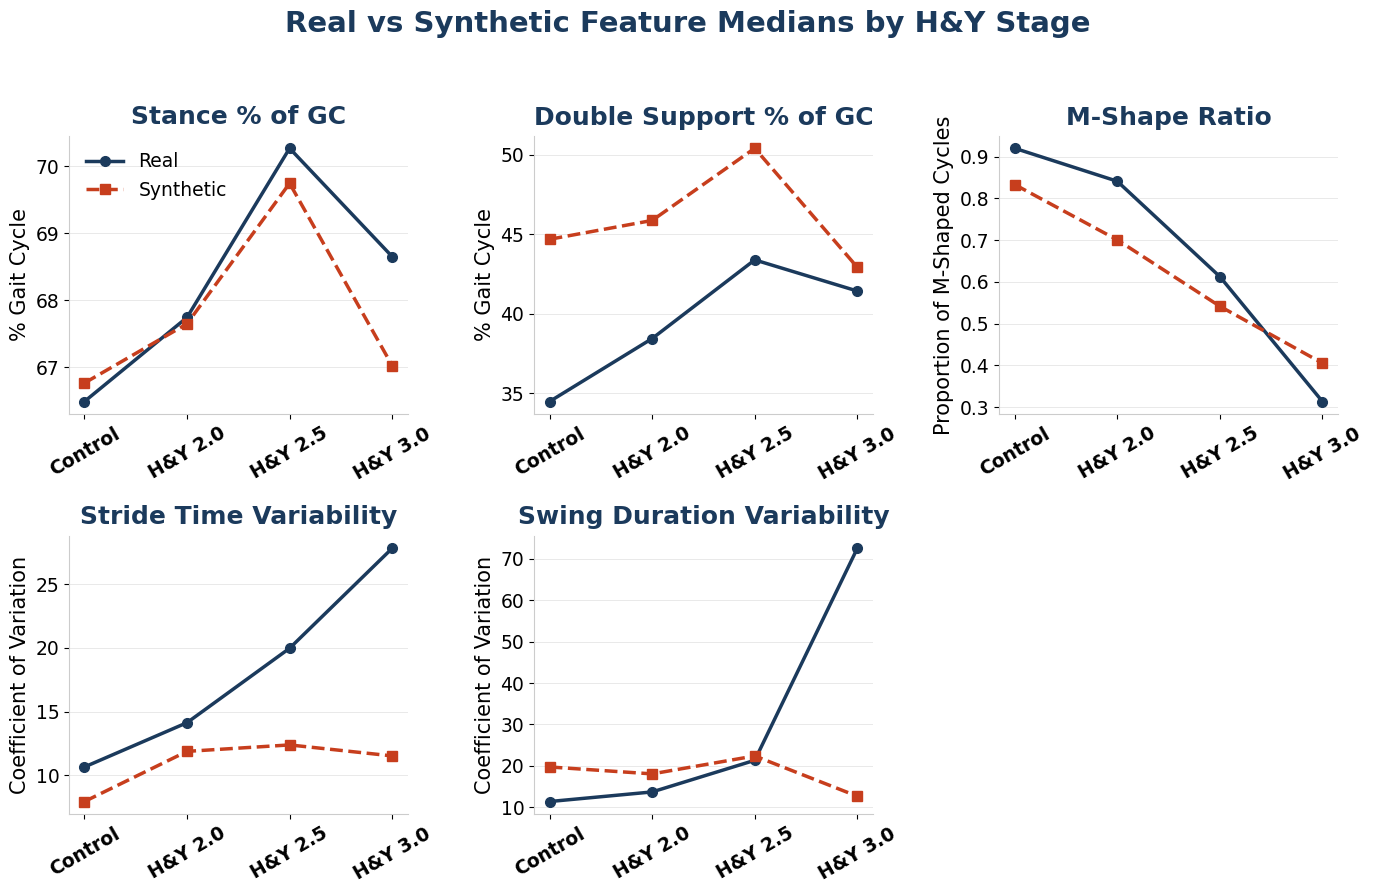

In [142]:
# --- Feature metadata ---
REAL_FEATURES = [
    ('mshape_ratio',            'M-Shape Ratio',              'Proportion of M-Shaped Cycles'),
    ('swing_dur_cv',            'Swing Duration Variability', 'Coefficient of Variation'),
    ('stride_time_cv',          'Stride Time Variability',    'Coefficient of Variation'),
    ('double_support_time_pct', 'Double Support % of GC',     '% Gait Cycle'),
    ('stance_pct_gc',           'Stance % of GC',             '% Gait Cycle'),
]

# Create lookup dict: feat -> (title, ylabel)
FEATURE_LABELS = {f: (title, ylabel) for f, title, ylabel in REAL_FEATURES}

# --- Styling ---
BG_COLOUR   = '#FFFFFF'
GRID_COLOUR = '#E0E0E0'
GROUP_ORDER = ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']

SCALE = 1.5
base = 10
plt.rcParams.update({
    'font.size':        base * SCALE,
    'axes.titlesize':   base * SCALE * 1.2,
    'axes.labelsize':   base * SCALE,
    'xtick.labelsize':  base * SCALE * 0.9,
    'ytick.labelsize':  base * SCALE * 0.9,
    'legend.fontsize':  base * SCALE * 0.9,
    'figure.titlesize': base * SCALE * 1.4,
})

# --- Create 2x3 grid ---
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.patch.set_facecolor(BG_COLOUR)

# --- Plot ---
for ax, (feat, cat, real_df, syn_df) in zip(axes.flat, SELECTED_FEATURES):
    ax.set_facecolor(BG_COLOUR)

    # Get display labels
    title, ylabel = FEATURE_LABELS.get(feat, (feat, ""))

    real_means = [get_group_values(real_df, feat, g).mean() for g in GROUP_ORDER]
    syn_means  = [get_group_values(syn_df,  feat, g).mean() for g in GROUP_ORDER]
    real_median = [np.median(get_group_values(real_df, feat, g)) for g in GROUP_ORDER]
    syn_median  = [np.median(get_group_values(syn_df,  feat, g)) for g in GROUP_ORDER]

    ax.plot(GROUP_ORDER, real_median, 'o-', color='#1B3A5C',
            linewidth=2.5, markersize=7, label='Real')
    ax.plot(GROUP_ORDER, syn_median,  's--', color='#C73E1D',
            linewidth=2.5, markersize=7, label='Synthetic')

    # --- Apply new labels ---
    ax.set_title(title, fontweight='bold', color='#1B3A5C', pad=8)
    ax.set_ylabel(ylabel)

    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontweight='bold', rotation=30)

    ax.grid(axis='y', color=GRID_COLOUR, linewidth=0.7, alpha=0.7)

    # Spine styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

# --- Legend (only once) ---
axes.flat[0].legend(loc='best', frameon=False)

# --- Hide unused subplot ---
if len(SELECTED_FEATURES) < len(axes.flat):
    axes.flat[len(SELECTED_FEATURES)].axis('off')

# --- Title ---
fig.suptitle('Real vs Synthetic Feature Medians by H&Y Stage',
             fontweight='bold', color='#1B3A5C', y=0.995)

# --- Layout + Save ---
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plot_real_vs_synthetic_medians.png', dpi=600,
            bbox_inches='tight', facecolor=BG_COLOUR)

plt.show()

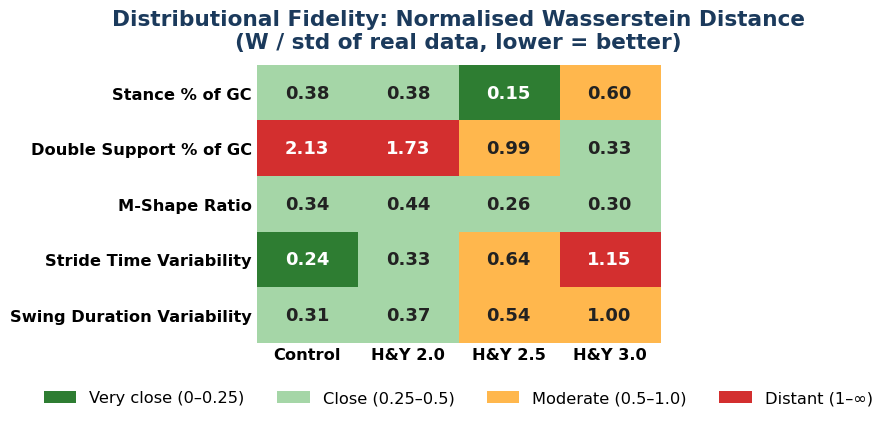

In [143]:
# --- Feature metadata ---
REAL_FEATURES = [
    ('mshape_ratio',            'M-Shape Ratio',              'Proportion of M-Shaped Cycles'),
    ('swing_dur_cv',            'Swing Duration Variability', 'Coefficient of Variation'),
    ('stride_time_cv',          'Stride Time Variability',    'Coefficient of Variation'),
    ('double_support_time_pct', 'Double Support % of GC',     '% Gait Cycle'),
    ('stance_pct_gc',           'Stance % of GC',             '% Gait Cycle'),
]

# Lookup dict: feat -> (title, ylabel)
FEATURE_LABELS = {f: (title, ylabel) for f, title, ylabel in REAL_FEATURES}

# --- Build pivot ---
pivot = dist_df.pivot(index='Feature', columns='Class', values='W / std_real')
pivot = pivot[GROUP_ORDER]

# Enforce ordering
feature_order = [f[0] for f in SELECTED_FEATURES]
pivot = pivot.loc[feature_order]

# --- Replace index with readable names ---
pivot.index = [FEATURE_LABELS.get(f, (f, ""))[0] for f in pivot.index]

# --- Styling ---
SCALE = 1.3
base = 10
plt.rcParams.update({
    'font.size':        base * SCALE,
    'axes.titlesize':   base * SCALE * 1.2,
    'axes.labelsize':   base * SCALE,
    'xtick.labelsize':  base * SCALE * 0.9,
    'ytick.labelsize':  base * SCALE * 0.9,
    'legend.fontsize':  base * SCALE * 0.9,
    'figure.titlesize': base * SCALE * 1.4,
})

# Fidelity bands
BAND_EDGES  = [0, 0.25, 0.5, 1.0, np.inf]
BAND_NAMES  = ['Very close', 'Close', 'Moderate', 'Distant']
BAND_COLOURS = ['#2E7D32', '#A5D6A7', '#FFB74D', '#D32F2F']

cmap = mcolors.ListedColormap(BAND_COLOURS)
norm = mcolors.BoundaryNorm(BAND_EDGES, cmap.N)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor(BG_COLOUR)

im = ax.imshow(pivot.values, cmap=cmap, norm=norm, aspect='auto')

# Axis labels
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels(GROUP_ORDER, fontweight='bold')

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontweight='bold')

# --- Numeric overlay ---
for i, feat in enumerate(pivot.index):
    for j, grp in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        band_idx = np.digitize(val, BAND_EDGES) - 1
        text_colour = 'white' if band_idx in (0, 3) else '#222222'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontweight='bold', color=text_colour)

# Title
ax.set_title('Distributional Fidelity: Normalised Wasserstein Distance\n'
             '(W / std of real data, lower = better)',
             fontweight='bold', color='#1B3A5C', pad=12)

ax.tick_params(axis='both', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, facecolor=BAND_COLOURS[i],
                  label=f'{BAND_NAMES[i]} ({BAND_EDGES[i]:g}–'
                        f'{BAND_EDGES[i+1] if not np.isinf(BAND_EDGES[i+1]) else "∞"})')
    for i in range(len(BAND_NAMES))
]

ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)

plt.tight_layout()
plt.savefig('plot_distributional_heatmap.png', dpi=600,
            bbox_inches='tight', facecolor=BG_COLOUR)

plt.show()

In [32]:
# ============================================================
# Check for out-of-range values in double_support_time_pct
# ============================================================

feat = 'double_support_time_pct'

# All rows with the feature
check_df = tf_df[['subject_id', 'hoehn_yahr', 'label', feat]].copy()

# Flag out-of-range values
check_df['hy_group'] = check_df['hoehn_yahr'].apply(
    lambda x: 'Control' if x == 0
    else f'H&Y {x:.1f}' if pd.notna(x)
    else 'Unknown'
)
out_of_range = check_df[(check_df[feat] < 0) | (check_df[feat] > 100)]

print(f"Total records: {len(check_df)}")
print(f"Out-of-range values (<0 or >100%): {len(out_of_range)}\n")

if len(out_of_range) > 0:
    print("Out-of-range records:")
    print(out_of_range.sort_values(feat).to_string(index=False))
    print()

    # Breakdown by H&Y group
    print("Count of out-of-range values by H&Y group:")
    print(out_of_range['hy_group'].value_counts().to_string())
    print()

    # Subjects affected (for potential recording-level investigation)
    print(f"Unique subjects with out-of-range values: "
          f"{out_of_range['subject_id'].nunique()}")
    print("Affected subject IDs:",
          out_of_range['subject_id'].unique().tolist())

# Impact assessment: summary stats by group, with and without outliers
print("\n" + "=" * 70)
print("  Impact of removing out-of-range values on summary statistics")
print("=" * 70)

clean = check_df[(check_df[feat] >= 0) & (check_df[feat] <= 100)]

print(f"\n{'Group':<10s}{'n (all)':>10s}{'mean (all)':>14s}{'std (all)':>12s}"
      f"{'n (clean)':>12s}{'mean (clean)':>14s}{'std (clean)':>12s}")
print('-' * 84)
for grp in ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']:
    all_vals   = check_df.loc[check_df['hy_group'] == grp, feat].dropna()
    clean_vals = clean.loc[clean['hy_group'] == grp, feat].dropna()
    print(f"{grp:<10s}"
          f"{len(all_vals):>10d}{all_vals.mean():>14.3f}{all_vals.std():>12.3f}"
          f"{len(clean_vals):>12d}{clean_vals.mean():>14.3f}{clean_vals.std():>12.3f}")

Total records: 300
Out-of-range values (<0 or >100%): 0


  Impact of removing out-of-range values on summary statistics

Group        n (all)    mean (all)   std (all)   n (clean)  mean (clean) std (clean)
------------------------------------------------------------------------------------
Control           91        34.724       5.797          91        34.724       5.797
H&Y 2.0          103        38.731       5.638         103        38.731       5.638
H&Y 2.5           80        44.942       7.286          80        44.942       7.286
H&Y 3.0           24        43.776       8.515          24        43.776       8.515


In [33]:
# ============================================================
# Sanity check: are JuPt26's other temporal features also broken?
# ============================================================

temporal_features_to_check = [
    'stance_dur', 'swing_dur', 'stance_pct_gc', 'swing_pct_gc',
    'stride_time', 'cadence', 'stance_swing_ratio',
    'double_support_time', 'double_support_time_pct', 'single_support_time'
]

# Expected physiological ranges (rough sanity bounds, not strict thresholds)
ranges = {
    'stance_dur':              (0.3, 1.5),   # seconds
    'swing_dur':               (0.2, 0.8),   # seconds
    'stance_pct_gc':           (50, 80),     # %
    'swing_pct_gc':            (20, 50),     # %
    'stride_time':             (0.7, 2.0),   # seconds
    'cadence':                 (30, 80),     # strides/min
    'stance_swing_ratio':      (1.0, 4.0),
    'double_support_time':     (0.05, 0.6),  # seconds
    'double_support_time_pct': (0, 100),     # %
    'single_support_time':     (0.1, 0.6),   # seconds
}

subject = 'JuPt26'
sub_df = tf_df[tf_df['subject_id'] == subject]
print(f"Subject {subject}: {len(sub_df)} records\n")

print(f"{'Feature':<26s}{'min':>10s}{'max':>10s}{'mean':>10s}"
      f"{'std':>10s}{'sanity range':>20s}{'  # out':>9s}")
print('-' * 95)
for feat in temporal_features_to_check:
    vals = sub_df[feat].dropna()
    lo, hi = ranges[feat]
    n_out = ((vals < lo) | (vals > hi)).sum()
    flag = '  <-- ' if n_out > 0 else ''
    print(f"{feat:<26s}{vals.min():>10.3f}{vals.max():>10.3f}"
          f"{vals.mean():>10.3f}{vals.std():>10.3f}"
          f"{f'[{lo}, {hi}]':>20s}{n_out:>9d}{flag}")

Subject JuPt26: 0 records

Feature                          min       max      mean       std        sanity range    # out
-----------------------------------------------------------------------------------------------
stance_dur                       nan       nan       nan       nan          [0.3, 1.5]        0
swing_dur                        nan       nan       nan       nan          [0.2, 0.8]        0
stance_pct_gc                    nan       nan       nan       nan            [50, 80]        0
swing_pct_gc                     nan       nan       nan       nan            [20, 50]        0
stride_time                      nan       nan       nan       nan          [0.7, 2.0]        0
cadence                          nan       nan       nan       nan            [30, 80]        0
stance_swing_ratio               nan       nan       nan       nan          [1.0, 4.0]        0
double_support_time              nan       nan       nan       nan         [0.05, 0.6]        0
double_suppor

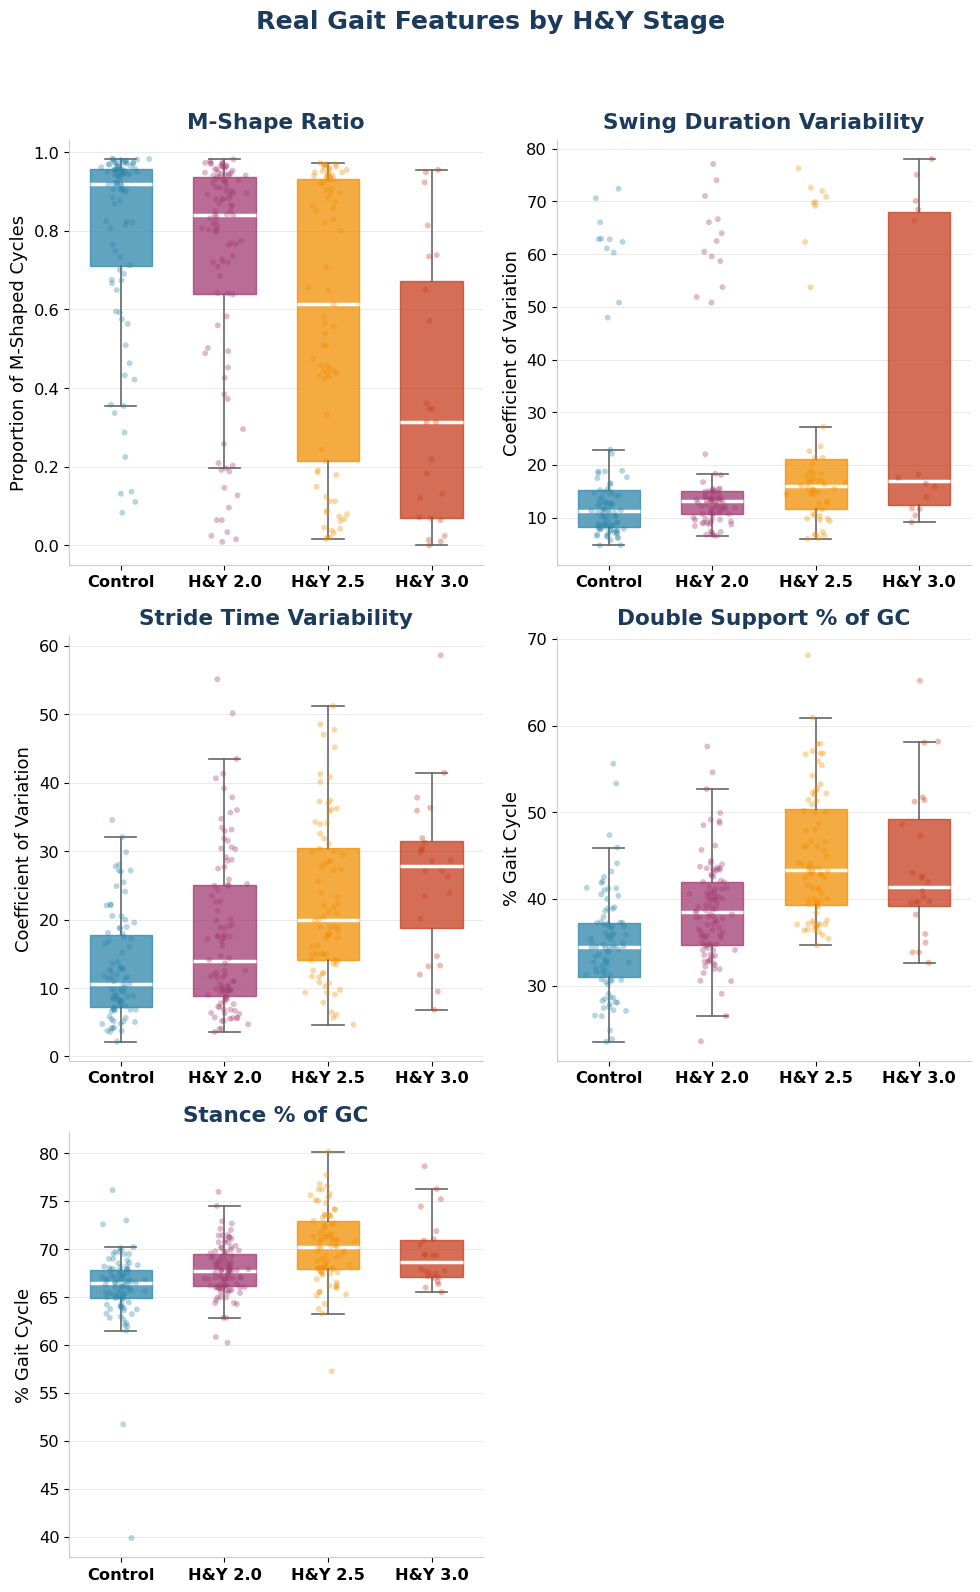

In [42]:
COLOURS = {
    'Control': '#2E86AB',
    'H&Y 2.0': '#A23B72',
    'H&Y 2.5': '#F18F01',
    'H&Y 3.0': '#C73E1D',
}
BG_COLOUR   = '#FFFFFF'
GRID_COLOUR = '#E0E0E0'
GROUP_ORDER = ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']

# (feature column, display title, y-axis label, source df, optional filter)
REAL_FEATURES = [
    ('mshape_ratio',            'M-Shape Ratio',              'Proportion of M-Shaped Cycles',           ff_df, None),
    ('swing_dur_cv',            'Swing Duration Variability', 'Coefficient of Variation', vf_df, 80),
    ('stride_time_cv',          'Stride Time Variability',    'Coefficient of Variation', vf_df, 80),
    ('double_support_time_pct', 'Double Support % of GC',             '% Gait Cycle',             tf_df, None),
    ('stance_pct_gc',           'Stance % of GC',                     '% Gait Cycle',             tf_df, None),
]

SCALE = 1.3
base = 10
plt.rcParams.update({
    'font.size':        base * SCALE,
    'axes.titlesize':   base * SCALE * 1.2,
    'axes.labelsize':   base * SCALE,
    'xtick.labelsize':  base * SCALE * 0.9,
    'ytick.labelsize':  base * SCALE * 0.9,
    'legend.fontsize':  base * SCALE * 0.9,
    'figure.titlesize': base * SCALE * 1.4,
})

def add_hy_group(df):
    df = df.copy()
    df['hy_group'] = df['hoehn_yahr'].apply(
        lambda x: 'Control' if x == 0
        else f'H&Y {x:.1f}' if pd.notna(x)
        else 'Unknown'
    )
    return df[df['hy_group'] != 'Unknown']


fig, axes = plt.subplots(3, 2, figsize=(10, 16))
fig.patch.set_facecolor(BG_COLOUR)

for ax, (feat, title, ylabel, df_src, cv_cap) in zip(axes.flat, REAL_FEATURES):
    ax.set_facecolor(BG_COLOUR)

    df_plot = add_hy_group(df_src)
    if cv_cap is not None:
        df_plot = df_plot[df_plot[feat] <= cv_cap]

    data_groups = [df_plot.loc[df_plot['hy_group'] == g, feat].dropna().values
                   for g in GROUP_ORDER]

    bp = ax.boxplot(data_groups, positions=range(len(GROUP_ORDER)), widths=0.6,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color='#666666', linewidth=1.2),
                    capprops=dict(color='#666666', linewidth=1.2))

    for i, patch in enumerate(bp['boxes']):
        colour = COLOURS[GROUP_ORDER[i]]
        patch.set_facecolor(colour)
        patch.set_alpha(0.75)
        patch.set_edgecolor(colour)

    # Jittered points
    for i, (group, vals) in enumerate(zip(GROUP_ORDER, data_groups)):
        jitter = np.random.normal(0, 0.08, size=len(vals))
        ax.scatter(np.full_like(vals, i) + jitter, vals,
                   c=COLOURS[group], alpha=0.35, s=18, zorder=3, edgecolors='none')

    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', color='#1B3A5C', pad=8)
    ax.grid(axis='y', color=GRID_COLOUR, linewidth=0.7, alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

# Hide the unused 6th axis
axes.flat[5].axis('off')

fig.suptitle('Real Gait Features by H&Y Stage', fontweight='bold', color='#1B3A5C', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plot_real_features_summary.png', dpi=600, bbox_inches='tight',
            facecolor=BG_COLOUR)
plt.show()

41


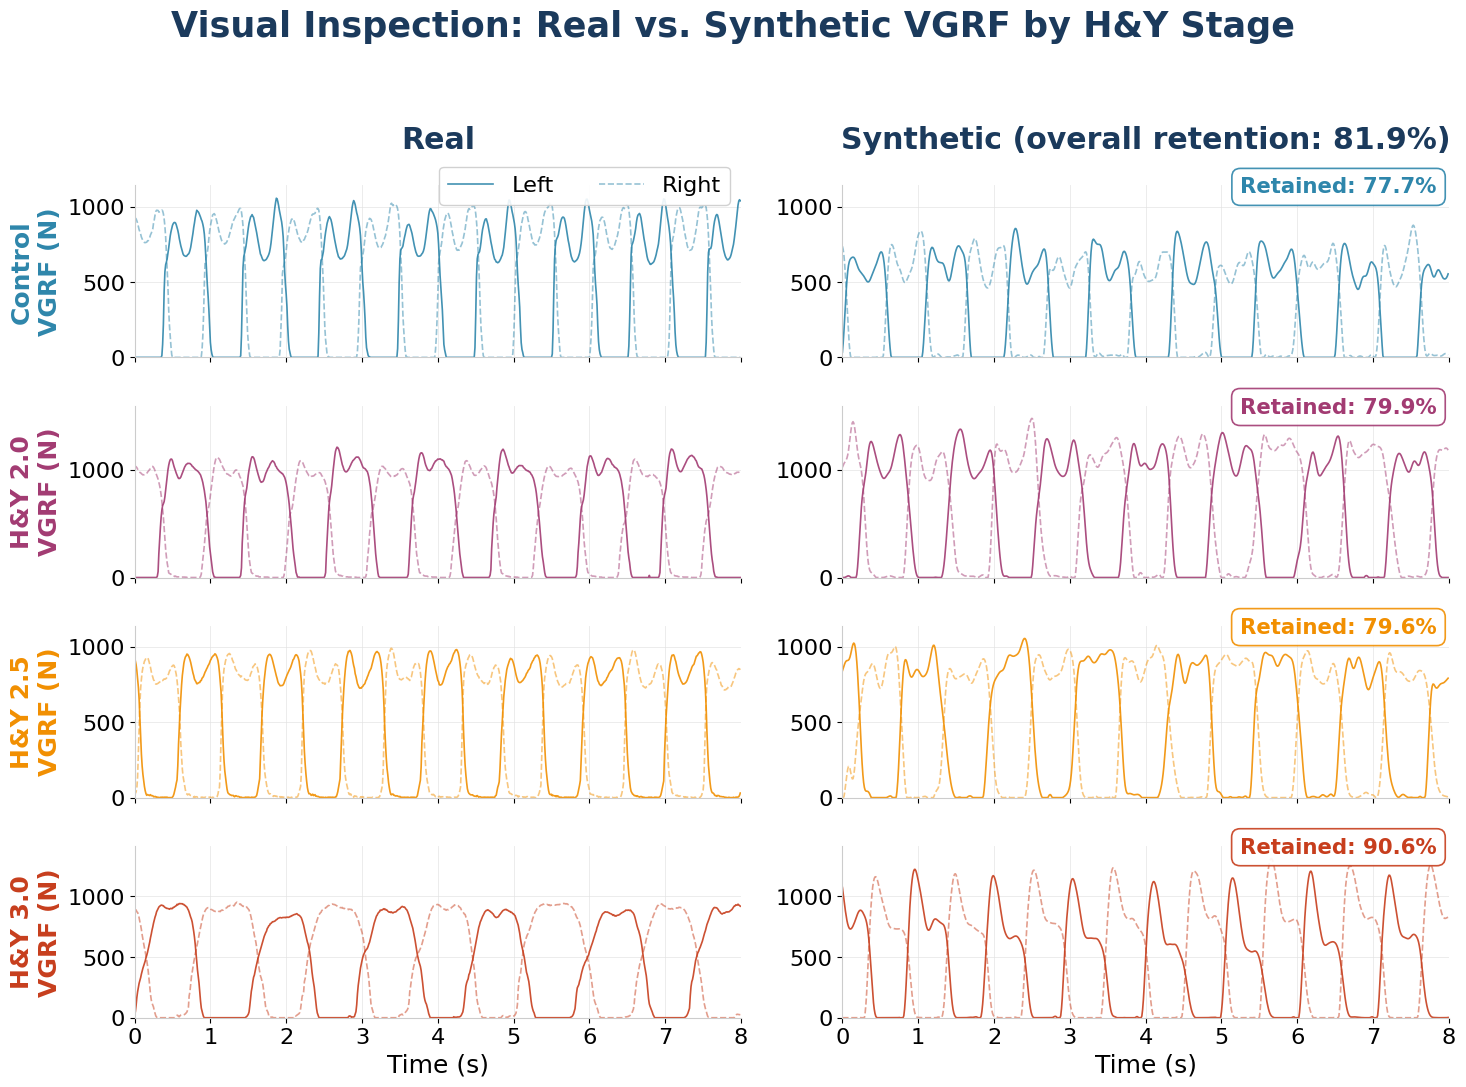

In [79]:
"""
Visual inspection: one real and one synthetic subject per H&Y class.
Each panel shows that subject's L_Total and R_Total VGRF traces.
Rows = H&Y class, Columns = Real | Synthetic.
Synthetic panels also show the post-generation filtering retention rate.
"""

COLOURS = {
    'Control': '#2E86AB',
    'H&Y 2.0': '#A23B72',
    'H&Y 2.5': '#F18F01',
    'H&Y 3.0': '#C73E1D',
}
BG_COLOUR   = '#FFFFFF'
GRID_COLOUR = '#E0E0E0'
group_order = ['Control', 'H&Y 2.0', 'H&Y 2.5', 'H&Y 3.0']

# Post-generation filtering retention rates (% of synthetic signals kept)
RETENTION_RATES = {
    'Control': 77.7,
    'H&Y 2.0': 79.9,
    'H&Y 2.5': 79.6,
    'H&Y 3.0': 90.6,
}
OVERALL_RETENTION = 81.9

RAW_SECONDS = 8           # duration of trace window
n = n + 1
RNG_REAL  = np.random.default_rng(18)
RNG_SYNTH = np.random.default_rng(39)

print(n)

def hy_to_group(hy):
    if hy == 0:   return 'Control'
    if hy == 2.0: return 'H&Y 2.0'
    if hy == 2.5: return 'H&Y 2.5'
    if hy == 3.0: return 'H&Y 3.0'
    return None


def records_by_group(records):
    buckets = {g: [] for g in group_order}
    for r in records:
        g = hy_to_group(r.get('hoehn_yahr'))
        if g is not None:
            buckets[g].append(r)
    return buckets


def pick_subject_window(records_in_group, n_samples, rng):
    """Return (time, L_trace, R_trace) for one random subject."""
    if len(records_in_group) == 0:
        return None
    idxs = rng.permutation(len(records_in_group))
    for i in idxs:
        rec = records_in_group[i]
        L, R = rec['L_Total'], rec['R_Total']
        if len(L) < n_samples or len(R) < n_samples:
            continue
        start = rng.integers(0, len(L) - n_samples)
        t = np.arange(n_samples) / SAMPLING_RATE
        return t, L[start:start + n_samples], R[start:start + n_samples]
    return None


real_buckets  = records_by_group(all_data)
synth_buckets = records_by_group(synth_records)
n_samples_raw = int(RAW_SECONDS * SAMPLING_RATE)

# ── Figure ──
fig, axes = plt.subplots(len(group_order), 2, figsize=(15, 11),
                         sharex='col')
fig.patch.set_facecolor(BG_COLOUR)

col_titles = ['Real', f'Synthetic (overall retention: {OVERALL_RETENTION:.1f}%)']
sources = [real_buckets, synth_buckets]

SCALE = 1.8
base = 10
plt.rcParams.update({
    'font.size':        base * SCALE,
    'axes.titlesize':   base * SCALE * 1.2,
    'axes.labelsize':   base * SCALE,
    'xtick.labelsize':  base * SCALE * 0.9,
    'ytick.labelsize':  base * SCALE * 0.9,
    'legend.fontsize':  base * SCALE * 0.9,
    'figure.titlesize': base * SCALE * 1.4,
})

sources = [real_buckets, synth_buckets]
rngs    = [RNG_REAL, RNG_SYNTH]

for row, group in enumerate(group_order):
    # Share y-limits across Real/Synth within a row
    row_windows = [pick_subject_window(src[group], n_samples_raw, rng)
                   for src, rng in zip(sources, rngs)]
    row_ymax = 0
    for w in row_windows:
        if w is not None:
            _, L, R = w
            row_ymax = max(row_ymax, float(np.max(L)), float(np.max(R)))
    row_ymax = row_ymax * 1.08 if row_ymax > 0 else 1

    for col, window in enumerate(row_windows):
        ax = axes[row, col]
        ax.set_facecolor(BG_COLOUR)
        colour = COLOURS[group]

        if window is not None:
            t, L, R = window
            ax.plot(t, L, color=colour, linewidth=1.2, alpha=0.9, label='Left')
            ax.plot(t, R, color=colour, linewidth=1.2, alpha=0.5,
                    linestyle='--', label='Right')
            if row == 0 and col == 0:
                ax.legend(loc='upper right', framealpha=0.9,
                          edgecolor='#CCCCCC', ncols=2, bbox_to_anchor = [1, 1.175])

        # Add retention annotation to synthetic panels (right column)
        if col == 1:
            retention = RETENTION_RATES[group]
            ax.text(0.98, 1.05,
                    f'Retained: {retention:.1f}%',
                    transform=ax.transAxes,
                    ha='right', va='top',
                    fontsize=base * SCALE * 0.85,
                    fontweight='bold',
                    color=colour,
                    bbox=dict(boxstyle='round,pad=0.4',
                              facecolor='white',
                              edgecolor=colour,
                              linewidth=1.2,
                              alpha=0.9))

        ax.set_ylim(0, row_ymax)
        ax.set_xlim(0, RAW_SECONDS)
        ax.grid(color=GRID_COLOUR, linewidth=0.7, alpha=0.6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#CCCCCC')
        ax.spines['bottom'].set_color('#CCCCCC')

        if row == 0:
            ax.set_title(col_titles[col], fontweight='bold',
                         color='#1B3A5C', pad=27)
        if col == 0:
            ax.set_ylabel(f'{group}\nVGRF (N)',
                          fontweight='bold', color=colour)
        if row == len(group_order) - 1:
            ax.set_xlabel('Time (s)')

fig.suptitle('Visual Inspection: Real vs. Synthetic VGRF by H&Y Stage',
             fontweight='bold', color='#1B3A5C', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('plot_visual_inspection_real_vs_synth.png', dpi=900,
            bbox_inches='tight', facecolor=BG_COLOUR)
plt.show()